# **Курсовая работа**

**На тему:** "Анализ данных о качестве воздуха с предварительной обработкой и визуализацией."<br>
**Выполнила:** Тарачева Екатерина

## Введение
В условиях нарастающих экологических проблем и стремительного роста урбанизации качество воздуха становится критически важным фактором, влияющим на здоровье населения, окружающую среду и устойчивое развитие городов. Загрязнение воздуха, вызванное выбросами промышленных предприятий, автотранспортом и другими источниками, требует систематического анализа и мониторинга. Данные о качестве воздуха, предоставляют ценную информацию, но их сложность, неоднородность и наличие шумов делают необходимой тщательную предварительную обработку и визуализацию для извлечения значимых закономерностей.

Для государственных органов, экологических организаций и исследователей важно не только собирать данные о качестве воздуха, но и классифицировать их по уровням загрязнения, чтобы оперативно реагировать на потенциальные угрозы. Точная классификация качества воздуха позволяет разрабатывать эффективные меры по снижению загрязнения, информировать население и прогнозировать экологические риски. В этом контексте предварительная обработка данных и их визуализация играют ключевую роль, обеспечивая наглядность и точность аналитических выводов.

С развитием технологий мониторинга и доступности больших объемов данных о качестве воздуха открываются новые возможности для применения методов машинного обучения. Использование индексов, таких как air_quality_us-epa-index или air_quality_gb-defra-index, в качестве целевых признаков позволяет решать задачу классификации, выявляя уровни загрязнения и их влияние на окружающую среду. Разработка надежных методов анализа и визуализации данных становится неотъемлемой частью экологических исследований, способствуя принятию обоснованных решений в области охраны окружающей среды.

**Цель**: анализ данных о качестве воздуха для классификации уровней загрязнения и выявления закономерностей, способствующих принятию экологически ориентированных решений.  
**Бизнес-задача**: на основе признаков данных о качестве воздуха определить категорию загрязнения для поддержки экологического мониторинга и информирования населения.  
**Задача машинного обучения**: многоклассовая классификация, где целевой признак определяет категорию качества воздуха.

## Предобработка и предварительный анализ данных

### Импорт и анализ датасета

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('GlobalWeatherRepository.csv')
data.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


Датасет взят с Kaggle. Его размер 60803 наблюдений × 41 признак. Собран за период 2024-05-16 - 2025-03-25. Датасет содержит данные о погоде и качестве воздуха для различных городов и стран. Он включает географические координаты, временную информацию, текущие погодные условия, а также показатели качества воздуха, такие как уровни твердых частиц PM2.5 и PM10, и индексы качества воздуха, рассчитанные по стандартам США и Великобритании. Дополнительно представлена информация о времени восхода и заката солнца и луны, а также о фазах и освещенности луны.   

**Признаки, связанные с местоположением и временем:**<br>
country: Название страны, где проводились измерения.<br>
location_name: Название конкретного города или местности.<br>
latitude: Географическая широта местоположения.<br>
longitude: Географическая долгота местоположения.<br>
timezone: Временная зона местоположения.<br>
last_updated_epoch: Время последнего обновления данных в формате Unix timestamp (количество секунд с 1 января 1970 года).<br>
last_updated: Время последнего обновления данных в строковом формате (год-месяц-день часы:минуты).<br>

**Признаки, связанные с погодными условиями:**<br>
temperature_celsius: Температура воздуха в градусах Цельсия.<br>
temperature_fahrenheit: Температура воздуха в градусах Фаренгейта.<br>
condition_text: Текстовое описание погодных условий (например, "Sunny", "Partly cloudy", "Rain").<br>
wind_mph: Скорость ветра в милях в час.<br>
wind_kph: Скорость ветра в километрах в час.<br>
wind_degree: Направление ветра в градусах (0-360).<br>
wind_direction: Буквенное обозначение направления ветра.<br>
pressure_mb: Атмосферное давление в миллибарах.<br>
pressure_in: Атмосферное давление в дюймах ртутного столба.<br>
precip_mm: Количество осадков в миллиметрах.<br>
precip_in: Количество осадков в дюймах.<br>
humidity: Относительная влажность воздуха в процентах (0-100).<br>
cloud: Облачность в процентах (0-100).<br>
feels_like_celsius: Ощущаемая температура в градусах Цельсия.<br>
feels_like_fahrenheit: Ощущаемая температура в градусах Фаренгейта.<br>
visibility_km: Видимость в километрах.<br>
visibility_miles: Видимость в милях.<br>
uv_index: Индекс ультрафиолетового излучения.<br>
gust_mph: Порывы ветра в милях в час.<br>
gust_kph: Порывы ветра в километрах в час.<br>

**Признаки, связанные с качеством воздуха:**<br>
air_quality_Carbon_Monoxide: Концентрация угарного газа (CO). Единицы измерения могут варьироваться (например, ppm - частей на миллион).<br>
air_quality_Ozone: Концентрация озона (O3). Единицы измерения могут варьироваться (например, ppm или мкг/м³).<br>
air_quality_Nitrogen_dioxide: Концентрация диоксида азота (NO2). Единицы измерения могут варьироваться (например, ppm или мкг/м³).<br>
air_quality_Sulphur_dioxide: Концентрация диоксида серы (SO2). Единицы измерения могут варьироваться (например, ppm или мкг/м³).<br>
air_quality_PM2.5: Концентрация твердых частиц PM2.5 (диаметром менее 2.5 микрометров). Единицы измерения обычно мкг/м³.<br>
air_quality_PM10: Концентрация твердых частиц PM10 (диаметром менее 10 микрометров). Единицы измерения обычно мкг/м³.<br>
air_quality_us-epa-index: Индекс качества воздуха, рассчитанный по стандартам Агентства по охране окружающей среды США (EPA). <br>
air_quality_gb-defra-index: Индекс качества воздуха, рассчитанный по стандартам Департамента окружающей среды, продовольствия и сельского хозяйства Великобритании (DEFRA).<br>

**Признаки, связанные с луной и солнцем:**<br>
sunrise: Время восхода солнца.<br>
sunset: Время заката солнца.<br>
moonrise: Время восхода луны.<br>
moonset: Время заката луны.<br>
moon_phase: Фаза луны.<br>
moon_illumination: Процент освещенности луны (0-100).<br>

### Удаление избыточных признаков

На начальном этапе предобработки данных было принято решение удалить ряд столбцов из исходного датасета, чтобы упростить анализ, снизить вычислительную нагрузку. Удаление следующих столбцов было обосновано их дублирующим характером:

Столбцы с дублирующими единицами измерения:
temperature_fahrenheit, feels_like_fahrenheit, wind_mph, gust_mph, pressure_in, precip_in, visibility_miles, last_updated_epoch будут удалены, так как они содержат ту же информацию, что и их аналоги в метрической системе (temperature_celsius, feels_like_celsius, wind_kph, gust_kph, pressure_mb, precip_mm, visibility_km, last_updated). Поскольку метрическая система является стандартом для научных исследований и обеспечивает единообразие данных, предпочтение было отдано метрическим показателям. Это позволило сократить объем датасета без потери информации.

Столбец air_quality_gb-defra-index представляющий индекс качества воздуха по стандартам Великобритании (DEFRA), будет удален, так как целевым признаком для задачи классификации выбран индекс air_quality_us-epa-index, рассчитанный по стандартам Агентства по охране окружающей среды США (EPA). Эти индексы отражают схожие характеристики качества воздуха, и их одновременное использование могло бы привести к избыточности и мультиколлинеарности, что негативно сказалось бы на качестве модели.

In [ ]:
columns_to_drop = [
    'temperature_fahrenheit', 'feels_like_fahrenheit',
    'wind_mph', 'gust_mph',
    'pressure_in',
    'precip_in',
    'visibility_miles',
    'air_quality_gb-defra-index',
    'last_updated_epoch',
    'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'
]

data = data.drop(columns_to_drop, axis = 1)
data.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index'],
      dtype='object')

### Вывод количественных характеристик датасета и информации о пропущенных значениях

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60803 entries, 0 to 60802
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       60803 non-null  object 
 1   location_name                 60803 non-null  object 
 2   latitude                      60803 non-null  float64
 3   longitude                     60803 non-null  float64
 4   timezone                      60803 non-null  object 
 5   last_updated                  60803 non-null  object 
 6   temperature_celsius           60803 non-null  float64
 7   condition_text                60803 non-null  object 
 8   wind_kph                      60803 non-null  float64
 9   wind_degree                   60803 non-null  int64  
 10  wind_direction                60803 non-null  object 
 11  pressure_mb                   60803 non-null  float64
 12  precip_mm                     60803 non-null  float64
 13  h

Можно заметить, что явных пропусков в данных нет.

### Определение шкалы измерения каждого признака

*Численные признаки:*<br>
**latitude, longitude**: Интервальная шкала. Географические координаты представляют собой числовые значения с равными интервалами, но без абсолютного нуля (например, 0° широты — не отсутствие широты).<br>
**temperature_celsius, feels_like_celsius**: Интервальная шкала. Температура измеряется в градусах с равными интервалами, но без абсолютного нуля (0°C — не отсутствие температуры).<br>
**wind_kph, gust_kph, wind_degree**: Относительная шкала для wind_kph и gust_kph (скорость ветра и порывов имеет абсолютный нуль — отсутствие движения), порядковая для wind_degree (направление ветра в градусах, где порядок имеет значение, но интервалы условны).<br>
**pressure_mb**: Относительная шкала. Атмосферное давление имеет абсолютный нуль (0 мбар — отсутствие давления), хотя в реальных условиях минимальные значения сильно отличаются.<br>
**precip_mm**: Относительная шкала. Количество осадков измеряется в миллиметрах с абсолютным нулем (0 мм — отсутствие осадков).<br>
**humidity, cloud**: Порядковая шкала. Проценты влажности и облачности (0–100%) имеют порядок, но интервалы между значениями условны и не всегда равны по значимости.<br>
**visibility_km**: Относительная шкала. Видимость имеет абсолютный нуль (0 км — полная отсутствие видимости), что делает её количественной.<br>
**uv_index**: Порядковая шкала. Индекс УФ-излучения имеет порядок (например, 1 < 10), но интервалы между значениями не равны по физическому эффекту.<br>
**air_quality_Carbon_Monoxide, air_quality_Ozone, air_quality_Nitrogen_dioxide, air_quality_Sulphur_dioxide, air_quality_PM2.5, air_quality_PM10**: Относительная шкала. Концентрации загрязнителей имеют абсолютный нуль (0 мкг/м³ — отсутствие вещества), что делает их количественными.<br>
**air_quality_us-epa-index**: Порядковая шкала. Индекс качества воздуха (1–6) имеет порядок (1 — лучшее качество, 6 — худшее), но интервалы между уровнями не равны по степени загрязнения.<br>
*Категориальные признаки:*<br>
**country, location_name, timezone, condition_text, wind_direction**: Номинальная шкала. Эти признаки представляют категории без естественного порядка.

## Обработка пропущенных значений и выбросов численных признаков

In [ ]:
data.describe()

,latitude,longitude,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
count,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000,60803.000000
mean,19.135905,22.182358,22.145427,13.338567,169.128661,1014.178823,0.140366,63.678470,40.107199,23.055318,9.589170,4.031892,19.105154,528.646607,63.570434,15.144636,11.421238,25.598978,51.628282,1.730721
std,24.475598,65.816073,9.623405,14.791568,103.672367,13.484127,0.606438,24.413171,33.933073,11.451529,2.533712,3.602540,16.649430,938.135704,36.121693,26.370846,48.438844,44.573881,160.044136,0.994046
min,-41.300000,-175.200000,-24.900000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,-35.600000,0.000000,0.000000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.185000,-1848.150000,1.000000
25%,3.750000,-6.836100,16.800000,6.500000,80.000000,1010.000000,0.000000,46.000000,3.000000,16.800000,10.000000,0.800000,10.800000,227.000000,39.000000,0.925000,0.740000,5.735000,8.880000,1.000000
50%,17.250000,23.316700,25.000000,11.200000,160.000000,1013.000000,0.000000,69.000000,31.000000,25.900000,10.000000,3.600000,16.600000,327.450000,60.800000,3.500000,2.300000,13.690000,20.905000,1.000000
75%,40.400000,50.580000,28.400000,18.400000,256.000000,1018.000000,0.030000,83.000000,75.000000,30.900000,10.000000,7.000000,25.500000,508.750000,83.000000,16.650000,8.880000,29.970000,46.065000,2.000000
max,64.150000,179.220000,49.200000,2963.200000,360.000000,3006.000000,42.240000,100.000000,100.000000,51.200000,32.000000,16.300000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000


**Отрицательные значения в столбцах, где они не ожидаются:**<br>
air_quality_Carbon_Monoxide: Минимальное значение -9999.0. Это явно аномалия, так как концентрация угарного газа не может быть отрицательной. Вероятно, это индикатор пропущенных или некорректных данных.<br>
air_quality_Sulphur_dioxide: Минимальное значение -9999.0. Аналогично, отрицательные значения для концентрации диоксида серы невозможны.<br>
air_quality_PM10: Минимальное значение -1848.15. Отрицательные значения для твердых частиц физически невозможны.

In [ ]:
print("air_quality_Carbon_Monoxide:", (data['air_quality_Carbon_Monoxide'] < 0).sum())
print("air_quality_Sulphur_dioxide:", (data['air_quality_Sulphur_dioxide'] < 0).sum())
print("air_quality_PM10:", (data['air_quality_PM10'] < 0).sum())

air_quality_Carbon_Monoxide: 1
air_quality_Sulphur_dioxide: 1
air_quality_PM10: 1


Есть предложение, что так как у каждого из этих признаков только одно отрицательное значение, то есть шанс, что это был общий сбой и эти ошибки находяться в одной строке, проверю эту теорию

In [ ]:
data[(data['air_quality_Carbon_Monoxide'] < 0) &
                   (data['air_quality_Sulphur_dioxide'] < 0) &
                   (data['air_quality_PM10'] < 0)]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index


Итак теория не подтвердилась, но в любом случае таких строчек всего 3 так что мы можем спокойно их удалить

In [ ]:
data = data.drop(index=data[
    (data['air_quality_Carbon_Monoxide'] < 0) |
    (data['air_quality_Sulphur_dioxide'] < 0) |
    (data['air_quality_PM10'] < 0)
].index, axis=0)

**Так же стоит обратить внимание на:**<br>
wind_kph: Максимум 2963.2 км/ч. Это нереалистично, так как даже ураганы редко превышают 200–300 км/ч. Вероятно, это ошибка ввода данных.<br>
gust_kph: Максимум 2970.4 км/ч. Аналогичная проблема, связанная с wind_kph.<br>
pressure_mb: Максимум 3006 мбар. Нормальное атмосферное давление находится в диапазоне 950–1050 мбар, так что 3006 мбар — явная аномалия.<br>
**Эти значения тоже выглядят достаточно подозрительными, но вероятными, поэтому посмотрим при каких air_quality_us-epa-index, если при наихудших, то оставим, если нет, то будем думать:**<br>
air_quality_Carbon_Monoxide: Максимум 38879.398. Это экстремально высокое значение для концентрации CO, которое требует проверки (обычно значения в ppm или мкг/м³ находятся в гораздо меньшем диапазоне).<br>
air_quality_PM2.5: Максимум 1614.1 мкг/м³. Это очень высокий уровень, но теоретически возможен в условиях сильного загрязнения (например, при лесных пожарах). Стоит проверить распределение.<br>
air_quality_PM10: Максимум 6037.29 мкг/м³. Тоже возможно в экстремальных условиях, но выглядит подозрительно.

**Определим пороги для аномалий:**<br>
wind_kph: Максимум 2963.2 км/ч, нереально. Установим порог, например, >300 км/ч (выше скорости урагана).<br>
gust_kph: Максимум 2970.4 км/ч, тоже нереально. Порог >300 км/ч.<br>
pressure_mb: Максимум 3006 мбар, не соответствует нормальному диапазону 950–1050 мбар. Порог >1050 мбар или <950 мбар.<br>

air_quality_Carbon_Monoxide: Максимум 38879.398 мкг/м³. Обычно CO в воздухе <10000 мкг/м³ даже в загрязненных зонах. Порог >10000 мкг/м³.
air_quality_PM2.5: Максимум 1614.1 мкг/м³, возможно в экстремальных условиях (например, смог, пожары). Порог >500 мкг/м³ для проверки.
air_quality_PM10: Максимум 6037.29 мкг/м³, тоже возможно в экстремальных условиях. Порог >1000 мкг/м³.

In [ ]:
wind_kph_threshold = 300
gust_kph_threshold = 300
pressure_mb_upper = 1050
pressure_mb_lower = 950

In [ ]:
co_threshold = 10000
pm25_threshold = 500
pm10_threshold = 1000

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
data[data['wind_kph'] > wind_kph_threshold]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
7601,Burundi,Bujumbura,-3.38,29.36,Africa/Bujumbura,2024-06-23 15:45,22.5,Partly cloudy,2963.2,180,S,1014.0,0.0,52,25,24.6,10.0,7.0,2970.4,277.0,52.2,0.6,0.2,5.3,7.2,1


In [ ]:
data[data['gust_kph'] > gust_kph_threshold]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
7601,Burundi,Bujumbura,-3.38,29.36,Africa/Bujumbura,2024-06-23 15:45,22.5,Partly cloudy,2963.2,180,S,1014.0,0.0,52,25,24.6,10.0,7.0,2970.4,277.0,52.2,0.6,0.2,5.3,7.2,1


Эту строчку удалю, так как она одна и это явная ошибка, так как значение очень велико, и другие признаки не указывают, на то что в этом месте какое то анамальное положение

In [ ]:
data = data.drop(index=7601, axis=0)

In [ ]:
data[(data['pressure_mb'] > pressure_mb_upper) | (data['pressure_mb'] < pressure_mb_lower)]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
38510,Jordan,Amman,31.9500,35.9333,Asia/Amman,2024-12-01 14:00,16.2,Mist,10.8,310,NW,1080.0,0.00,42,0,16.2,4.0,2.9,12.4,240.500,82.0,8.140,32.930,15.170,24.975,1
49003,Kazakhstan,Astana,51.1811,71.4278,Asia/Almaty,2025-01-24 15:30,-23.6,Sunny,16.6,196,SSW,1052.0,0.00,63,0,-34.0,10.0,0.4,24.9,945.350,63.0,15.910,20.350,16.465,17.760,2
49769,Honduras,Tegucigalpa,14.1000,-87.2167,America/Tegucigalpa,2025-01-28 05:00,19.1,Partly cloudy,10.4,15,NNE,3006.0,0.02,88,50,19.1,10.0,0.0,18.3,329.300,77.0,2.035,1.480,6.660,8.140,1
50941,Iceland,Vestmannaeyjar,63.3650,-20.2075,Atlantic/Reykjavik,2025-02-03 10:30,4.0,Moderate rain,25.9,197,SSW,947.0,1.05,100,100,-0.9,10.0,0.0,37.4,262.568,88.0,0.184,0.367,4.590,24.421,1
51700,Estonia,Tallinn,59.4339,24.7281,Europe/Tallinn,2025-02-07 12:30,0.1,Partly cloudy,11.5,163,SSE,1051.0,0.00,74,75,-3.6,10.0,0.5,16.8,468.050,46.0,22.385,2.960,21.830,25.715,2
51704,Finland,Helsinki,60.1756,24.9342,Europe/Helsinki,2025-02-07 12:30,-0.8,Overcast,11.2,172,S,1052.0,0.00,93,75,-4.6,10.0,0.4,15.0,427.350,42.0,28.490,3.515,14.430,17.020,1
51788,Russia,Moscow,55.7522,37.6156,Europe/Moscow,2025-02-07 13:30,-3.8,Partly cloudy,11.2,70,ENE,1051.0,0.00,68,50,-8.2,10.0,0.7,14.3,723.350,40.0,82.510,88.985,52.725,64.010,3
52114,Iran,Tehran,35.7261,51.3304,Asia/Tehran,2025-02-09 14:00,2.1,Overcast,8.3,268,W,3000.0,0.02,60,100,-0.4,9.0,1.6,9.5,3146.850,40.0,118.030,56.610,51.430,52.725,3


Значения 3000 и 3006 мбар (Тегеран и Тегусигальпа) физически нереальны, так как атмосферное давление на уровне моря не превышает ~1080 мбар даже в экстремальных условиях (например, в антициклонах).

Значения 1051–1080 мбар (Амман, Астана, Таллин, Хельсинки, Москва) слегка выше нормального диапазона (950–1050 мбар). Это может быть связано с:<br>
Высоким атмосферным давлением в зимние месяцы (все строки датированы декабрем 2024 – февралем 2025).<br>
Высотой над уровнем моря (например, Амман находится на высоте ~800 м, что может немного повлиять на давление).<br>
Значение 947 мбар (Вестманнаэйяр, Исландия) ниже нормы, но возможно в условиях шторма или циклона, особенно в этом регионе.

Принимаю решение, удалить две строчки с нереально высоким атмосферным давлениям, а другие оставить, так как их значения близкие к аномальным оправданны другими факторами.

In [ ]:
data = data.drop(index=[49769, 52114], axis=0)

Теперь посмотрим на другие подозрительные значения, но рельные при плохом качестве воздуха

In [ ]:
data[data['air_quality_Carbon_Monoxide'] > co_threshold]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
273,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-16 21:00,29.0,Mist,15.1,100,E,1010.0,2.05,84,75,34.5,5.0,1.0,22.3,19653.301,0.0,224.800,89.700,492.500,621.500,6
468,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-17 23:00,28.0,Mist,3.6,80,E,1009.0,0.06,74,25,30.9,5.0,1.0,12.2,24566.699,0.0,241.300,91.600,798.500,1002.200,6
660,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-18 21:30,28.0,Partly cloudy,11.2,200,SSW,1010.0,0.76,74,25,31.6,6.0,1.0,16.1,13565.100,0.0,127.500,71.500,278.200,376.600,6
854,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-19 21:15,30.0,Partly cloudy,15.1,70,ENE,1008.0,0.22,75,50,36.0,8.0,1.0,22.3,11322.000,0.0,159.000,59.100,244.700,319.000,5
1049,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-20 21:45,30.0,Partly cloudy,13.0,120,ESE,1009.0,0.11,70,25,34.7,8.0,1.0,14.5,22644.000,0.0,124.800,92.500,498.600,647.900,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47588,China,Beijing,39.9289,116.3883,Asia/Shanghai,2025-01-17 18:30,0.4,Clear,3.6,279,W,1023.0,0.00,24,0,-0.4,10.0,0.0,4.1,10028.800,9.0,89.910,283.975,347.985,356.680,6
49147,China,Beijing,39.9289,116.3883,Asia/Shanghai,2025-01-25 18:15,1.3,Clear,3.6,236,WSW,1033.0,0.00,55,0,0.6,6.0,0.0,10.8,12004.700,3.0,131.350,486.180,582.380,590.890,6
56205,Indonesia,Jakarta,-6.2146,106.8451,Asia/Jakarta,2025-03-02 16:45,30.3,Partly cloudy,13.7,1,N,1005.0,0.00,75,50,33.6,10.0,2.2,15.7,11283.200,72.0,155.030,131.905,253.265,253.265,6
57763,Indonesia,Jakarta,-6.2146,106.8451,Asia/Jakarta,2025-03-10 16:45,29.0,Partly cloudy,14.0,12,NNE,1008.0,0.71,75,25,32.2,10.0,0.9,18.2,10580.200,31.0,157.065,138.380,111.185,111.185,4


Данные: 92 строки с air_quality_Carbon_Monoxide выше порога 10000 мкг/м³.<br>
Ключевые наблюдения:<br>
air_quality_us-epa-index: Все строки имеют индекс 4–6 (в основном 6, "Hazardous", несколько строк с 5, "Very Unhealthy").<br>
География: Преимущественно Джакарта (Индонезия) и Пекин (Китай), известные высоким уровнем загрязнения.<br>
Погодные условия:<br>
Часто Mist или Partly cloudy, низкая видимость (visibility_km = 5–8), высокая влажность (humidity = 70–84%), что типично для условий смога.<br>
Другие загрязнители: Высокие значения air_quality_PM2.5 (до 798.5 мкг/м³) и air_quality_PM10 (до 1002.2 мкг/м³), что подтверждает сильное загрязнение.

In [ ]:
data[data['air_quality_PM2.5'] > pm25_threshold]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
230,Chile,Santiago,-33.4500,-70.6700,America/Santiago,2024-05-16 10:00,2.0,Sunny,6.8,60,ENE,1020.0,0.00,87,0,1.4,6.0,4.0,14.0,9719.900,19.7,181.000,66.800,714.100,873.400,6
468,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-17 23:00,28.0,Mist,3.6,80,E,1009.0,0.06,74,25,30.9,5.0,1.0,12.2,24566.699,0.0,241.300,91.600,798.500,1002.200,6
617,Chile,Santiago,-33.4500,-70.6700,America/Santiago,2024-05-18 10:30,5.0,Mist,3.6,217,SW,1024.0,0.00,75,50,4.7,5.0,5.0,10.8,7583.600,18.2,131.600,38.200,554.700,682.100,6
1006,Chile,Santiago,-33.4500,-70.6700,America/Santiago,2024-05-20 10:30,10.0,Mist,20.2,130,SE,1015.0,0.18,66,100,10.0,5.0,4.0,27.4,6675.700,1.0,109.700,31.000,502.100,565.700,6
1244,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-21 21:45,29.0,Mist,9.0,80,E,1009.0,0.23,79,25,32.9,5.0,1.0,10.7,37597.699,0.0,252.300,150.700,874.900,1072.800,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42945,China,Beijing,39.9289,116.3883,Asia/Shanghai,2024-12-24 18:15,0.7,Clear,3.6,298,WNW,1027.0,0.00,28,0,0.7,10.0,0.0,3.9,14211.700,7.0,136.900,457.690,625.485,628.815,6
45948,Saudi Arabia,Riyadh,24.6408,46.7728,Asia/Riyadh,2025-01-08 13:00,13.2,Partly cloudy,20.2,318,NW,1022.0,0.00,62,75,11.4,10.0,4.2,23.2,527.250,56.0,30.340,46.065,504.865,5044.770,6
49147,China,Beijing,39.9289,116.3883,Asia/Shanghai,2025-01-25 18:15,1.3,Clear,3.6,236,WSW,1033.0,0.00,55,0,0.6,6.0,0.0,10.8,12004.700,3.0,131.350,486.180,582.380,590.890,6
51601,Saudi Arabia,Riyadh,24.6408,46.7728,Asia/Riyadh,2025-02-06 13:15,27.4,Partly cloudy,28.1,237,WSW,1010.0,0.00,17,75,26.4,6.0,5.2,32.3,462.500,57.0,46.435,63.640,611.610,5899.280,6


Данные: 83 строки с air_quality_PM2.5 выше порога 500 мкг/м³.<br>
Ключевые наблюдения:<br>
air_quality_us-epa-index: Все строки, из тех что видно имеют индекс 6 ("Hazardous").<br>
География: Джакарта (Индонезия), Сантьяго (Чили), Эр-Рияд (Саудовская Аравия), Пекин (Китай).<br>
Погодные условия:<br>
Часто Mist, Sunny или Partly cloudy, низкая видимость (visibility_km = 4–6), что указывает на смог или пыльные бури.<br>
Другие загрязнители: Высокие air_quality_Carbon_Monoxide (до 24566.699) и air_quality_PM10 (до 6037.29), что подтверждает экстремальные условия.

In [ ]:
data[data['air_quality_PM10'] > pm10_threshold]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
468,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-17 23:00,28.0,Mist,3.6,80,E,1009.0,0.06,74,25,30.9,5.0,1.0,12.2,24566.699,0.0,241.300,91.600,798.500,1002.20,6
1244,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,2024-05-21 21:45,29.0,Mist,9.0,80,E,1009.0,0.23,79,25,32.9,5.0,1.0,10.7,37597.699,0.0,252.300,150.700,874.900,1072.80,6
2151,Azerbaijan,Baku,40.4000,49.8800,Asia/Baku,2024-05-26 18:00,23.0,Mist,15.1,110,ESE,1013.0,0.20,41,50,24.8,3.0,5.0,22.3,201.900,84.4,6.400,1.200,188.000,1261.40,5
2566,Chile,Santiago,-33.4500,-70.6700,America/Santiago,2024-05-28 10:30,7.0,Partly cloudy,6.8,30,NNE,1018.0,0.00,87,50,6.8,7.0,5.0,8.3,10467.500,11.2,175.500,70.600,981.800,1167.00,6
2955,Chile,Santiago,-33.4500,-70.6700,America/Santiago,2024-05-30 09:45,8.0,Mist,6.8,220,SW,1019.0,0.00,81,0,7.4,5.0,4.0,11.3,10147.100,1.6,134.400,66.800,1078.500,1245.50,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60381,Sudan,Juba,12.1500,24.4500,Africa/Khartoum,2025-03-23 11:45,24.1,Sunny,42.1,40,NE,1017.0,0.00,10,0,23.2,10.0,10.2,48.5,260.850,77.0,1.295,2.960,161.875,1016.58,5
60521,Mauritania,Nouakchott,18.0864,-15.9753,Africa/Nouakchott,2025-03-24 09:45,20.1,Sunny,29.2,31,NNE,1015.0,0.00,40,4,20.1,10.0,1.8,46.9,288.600,75.0,0.925,0.555,240.315,1154.40,5
60564,Saudi Arabia,Riyadh,24.6408,46.7728,Asia/Riyadh,2025-03-24 12:30,20.3,Sunny,26.6,354,N,1026.0,0.00,18,0,20.3,10.0,10.5,30.6,529.100,91.0,32.375,32.930,417.730,4603.73,6
60698,Kuwait,Kuwait City,29.3667,47.9600,Asia/Kuwait,2025-03-25 12:30,23.3,Sunny,27.4,314,NW,1018.0,0.00,17,0,23.5,10.0,7.9,34.6,344.100,71.0,33.670,25.900,173.530,1075.04,5


Данные: 191 строка с air_quality_PM10 выше порога 1000 мкг/м³.<br>
Ключевые наблюдения:<br>
air_quality_us-epa-index: Большинство строк имеют индекс 5–6 (в основном 6, несколько с 5, "Very Unhealthy").<br>
География: Джакарта, Сантьяго, Баку (Азербайджан), Эр-Рияд, Джуба (Судан), Нуакшот (Мавритания), Кувейт.<br>
Погодные условия:<br>
Часто Mist, Sunny, Partly cloudy, низкая видимость (visibility_km = 3–10), что может указывать на пыльную бурю, высокая скорость ветра может поднимать пыль. <br>
Другие загрязнители: Высокие air_quality_PM2.5 (до 874.9) и air_quality_Carbon_Monoxide (до 37597.699).

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60797 entries, 0 to 60802
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       60797 non-null  object 
 1   location_name                 60797 non-null  object 
 2   latitude                      60797 non-null  float64
 3   longitude                     60797 non-null  float64
 4   timezone                      60797 non-null  object 
 5   last_updated                  60797 non-null  object 
 6   temperature_celsius           60797 non-null  float64
 7   condition_text                60797 non-null  object 
 8   wind_kph                      60797 non-null  float64
 9   wind_degree                   60797 non-null  int64  
 10  wind_direction                60797 non-null  object 
 11  pressure_mb                   60797 non-null  float64
 12  precip_mm                     60797 non-null  float64
 13  humidi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Список численных признаков

In [ ]:
numeric_columns = [
    'latitude', 'longitude', 'temperature_celsius', 'wind_kph', 'wind_degree', 'pressure_mb',
    'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km',
    'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5',
    'air_quality_PM10'
]

Гистограммы с KDE для каждого численного признака

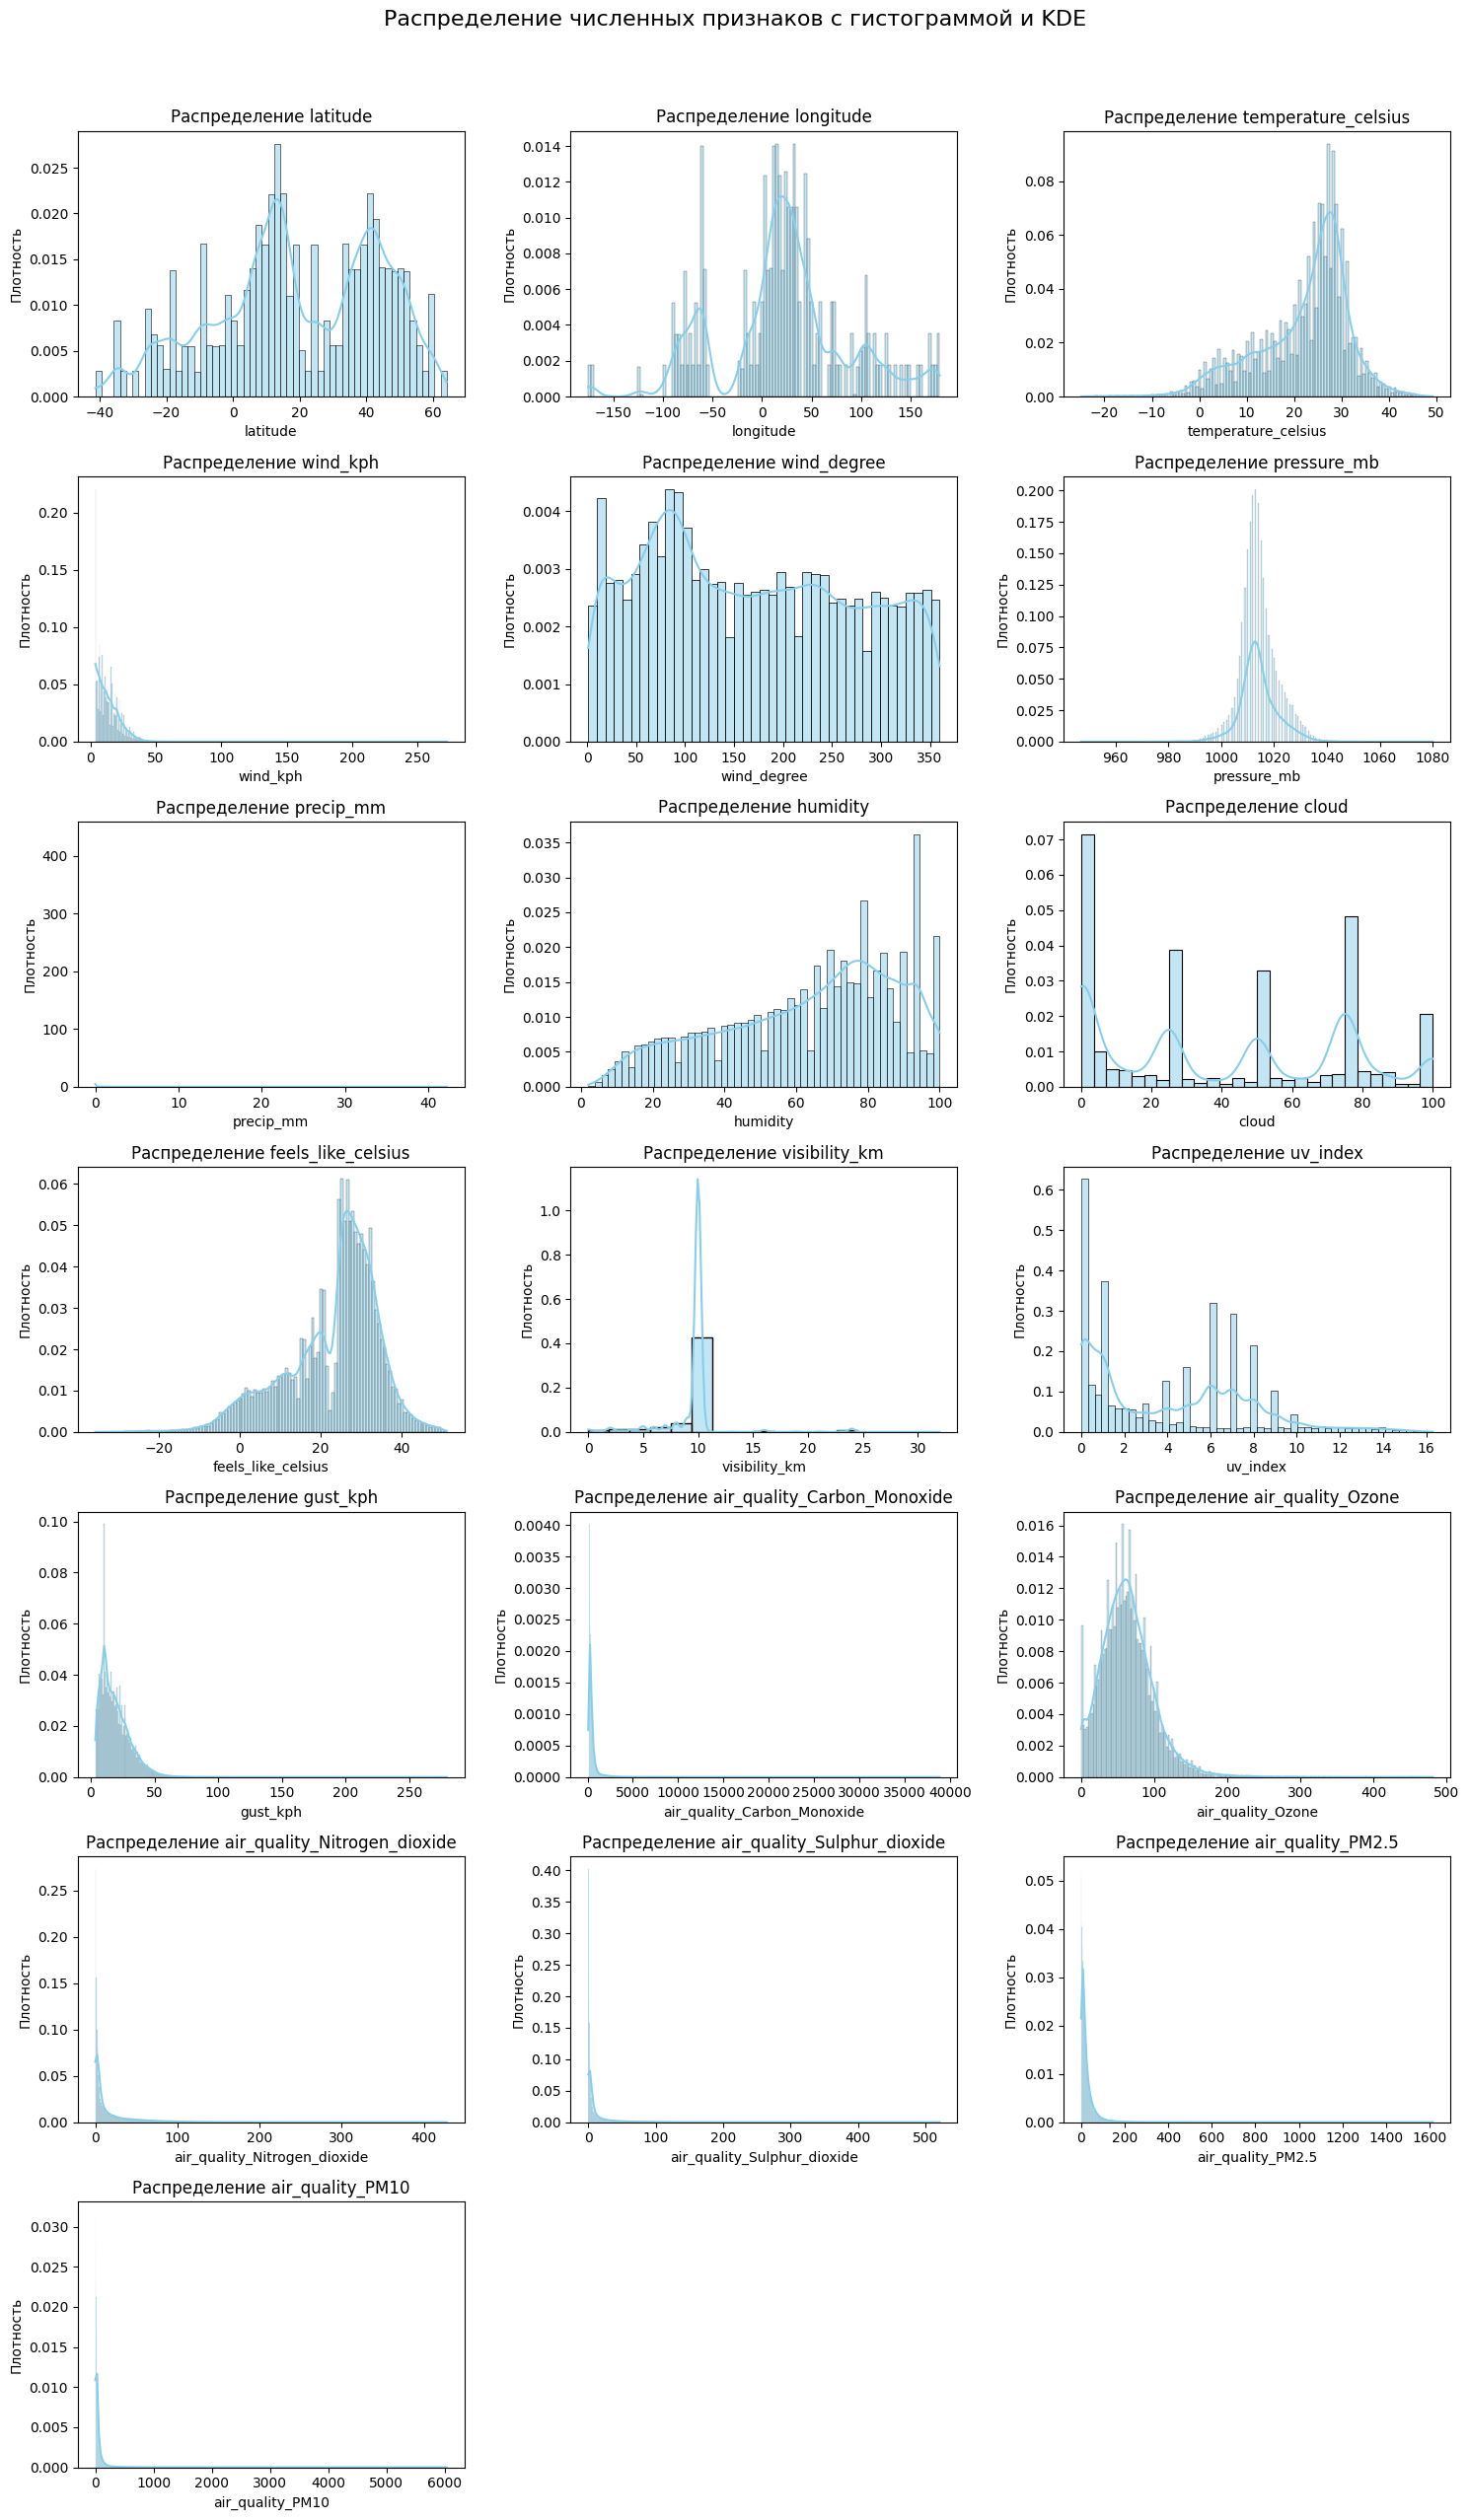

In [ ]:
plt.figure(figsize=(15, 25))
plt.suptitle('Распределение численных признаков с гистограммой и KDE', fontsize=16, y=1.02)
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(7, 3, i)
    sns.histplot(data[column], kde=True, stat="density", color='skyblue')
    plt.title(f'Распределение {column}')
    plt.xlabel(column)
    plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

Визуализация распределений численных признаков с помощью гистограмм и KDE показала, что признаки загрязнителей (например, air_quality_Carbon_Monoxide, air_quality_PM2.5, air_quality_PM10) имеют скошенные вправо распределения с редкими высокими значениями, что связано с экстремальными условиями загрязнения. Метеорологические признаки (например, temperature_celsius, wind_kph, pressure_mb) демонстрируют более узкие распределения с пиками в типичных диапазонах, а аномалии были успешно устранены на этапе предобработки. Анализ подтверждает пригодность данных для задачи классификации после проведенной очистки.

### Проверка на нормальность

На основе графиков можно сделать выводы, что большинство признаков в датасете имеют ненормальное распределение, что типично для экологических данных. Например, концентрации загрязнителей (air_quality_PM2.5, air_quality_PM10) и скорость ветра (wind_kph) имеют длинные правые хвосты из-за редких экстремальных значений, а humidity — U-образное распределение. Это не является проблемой для задачи многоклассовой классификации, так как большинство алгоритмов устойчивы к ненормальности.

KDE по группам для каждого численного признака в зависимости от air_quality_us-epa-index

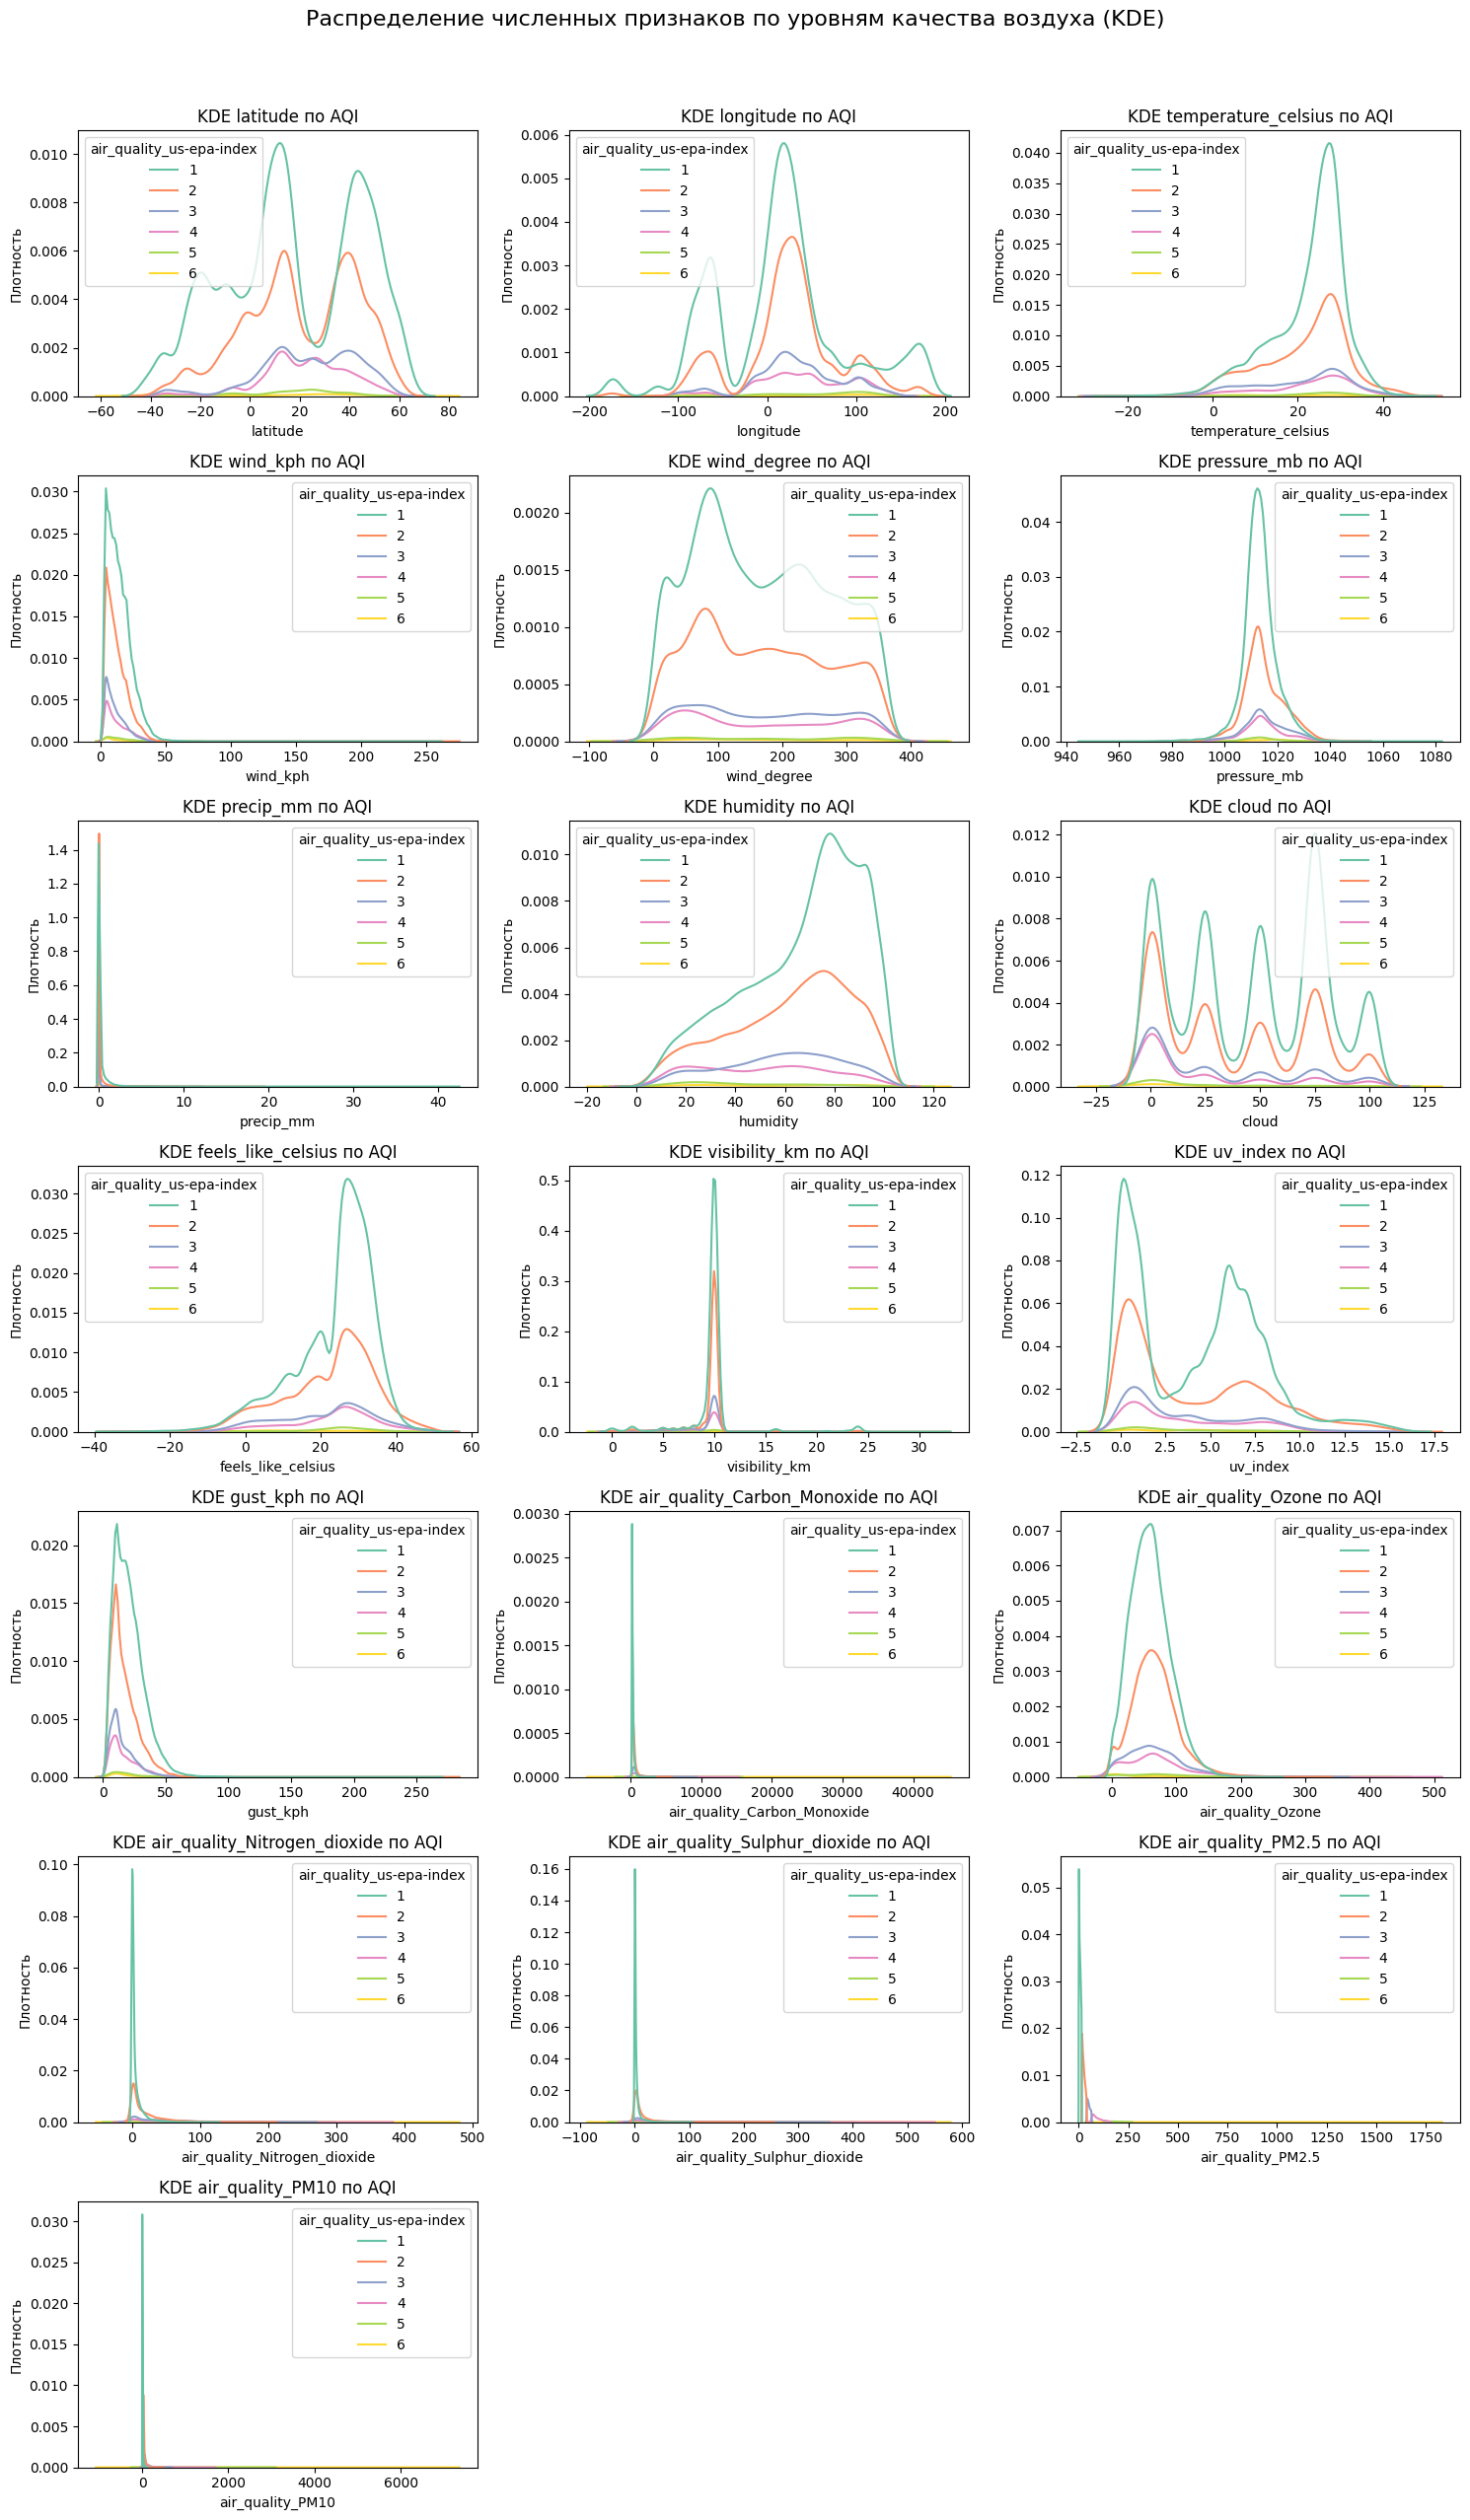

In [ ]:
plt.figure(figsize=(15, 25))
plt.suptitle('Распределение численных признаков по уровням качества воздуха (KDE)', fontsize=16, y=1.02)
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(7, 3, i)
    sns.kdeplot(data=data, x=column, hue='air_quality_us-epa-index', palette='Set2')
    plt.title(f'KDE {column} по AQI')
    plt.xlabel(column)
    plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

Анализ KDE распределений численных признаков по уровням air_quality_us-epa-index показал, что ключевыми факторами, влияющими на качество воздуха, являются концентрации загрязнителей (air_quality_Carbon_Monoxide, air_quality_PM2.5, air_quality_PM10, air_quality_Nitrogen_dioxide, air_quality_Sulphur_dioxide), которые демонстрируют значительные различия между классами. Данные подтверждают значимость загрязнителей как основных индикаторов качества воздуха, в то время как погодные условия играют вспомогательную роль, что делает их пригодными для дальнейшего моделирования классификации.

Ящики с усами для каждого численного признака:

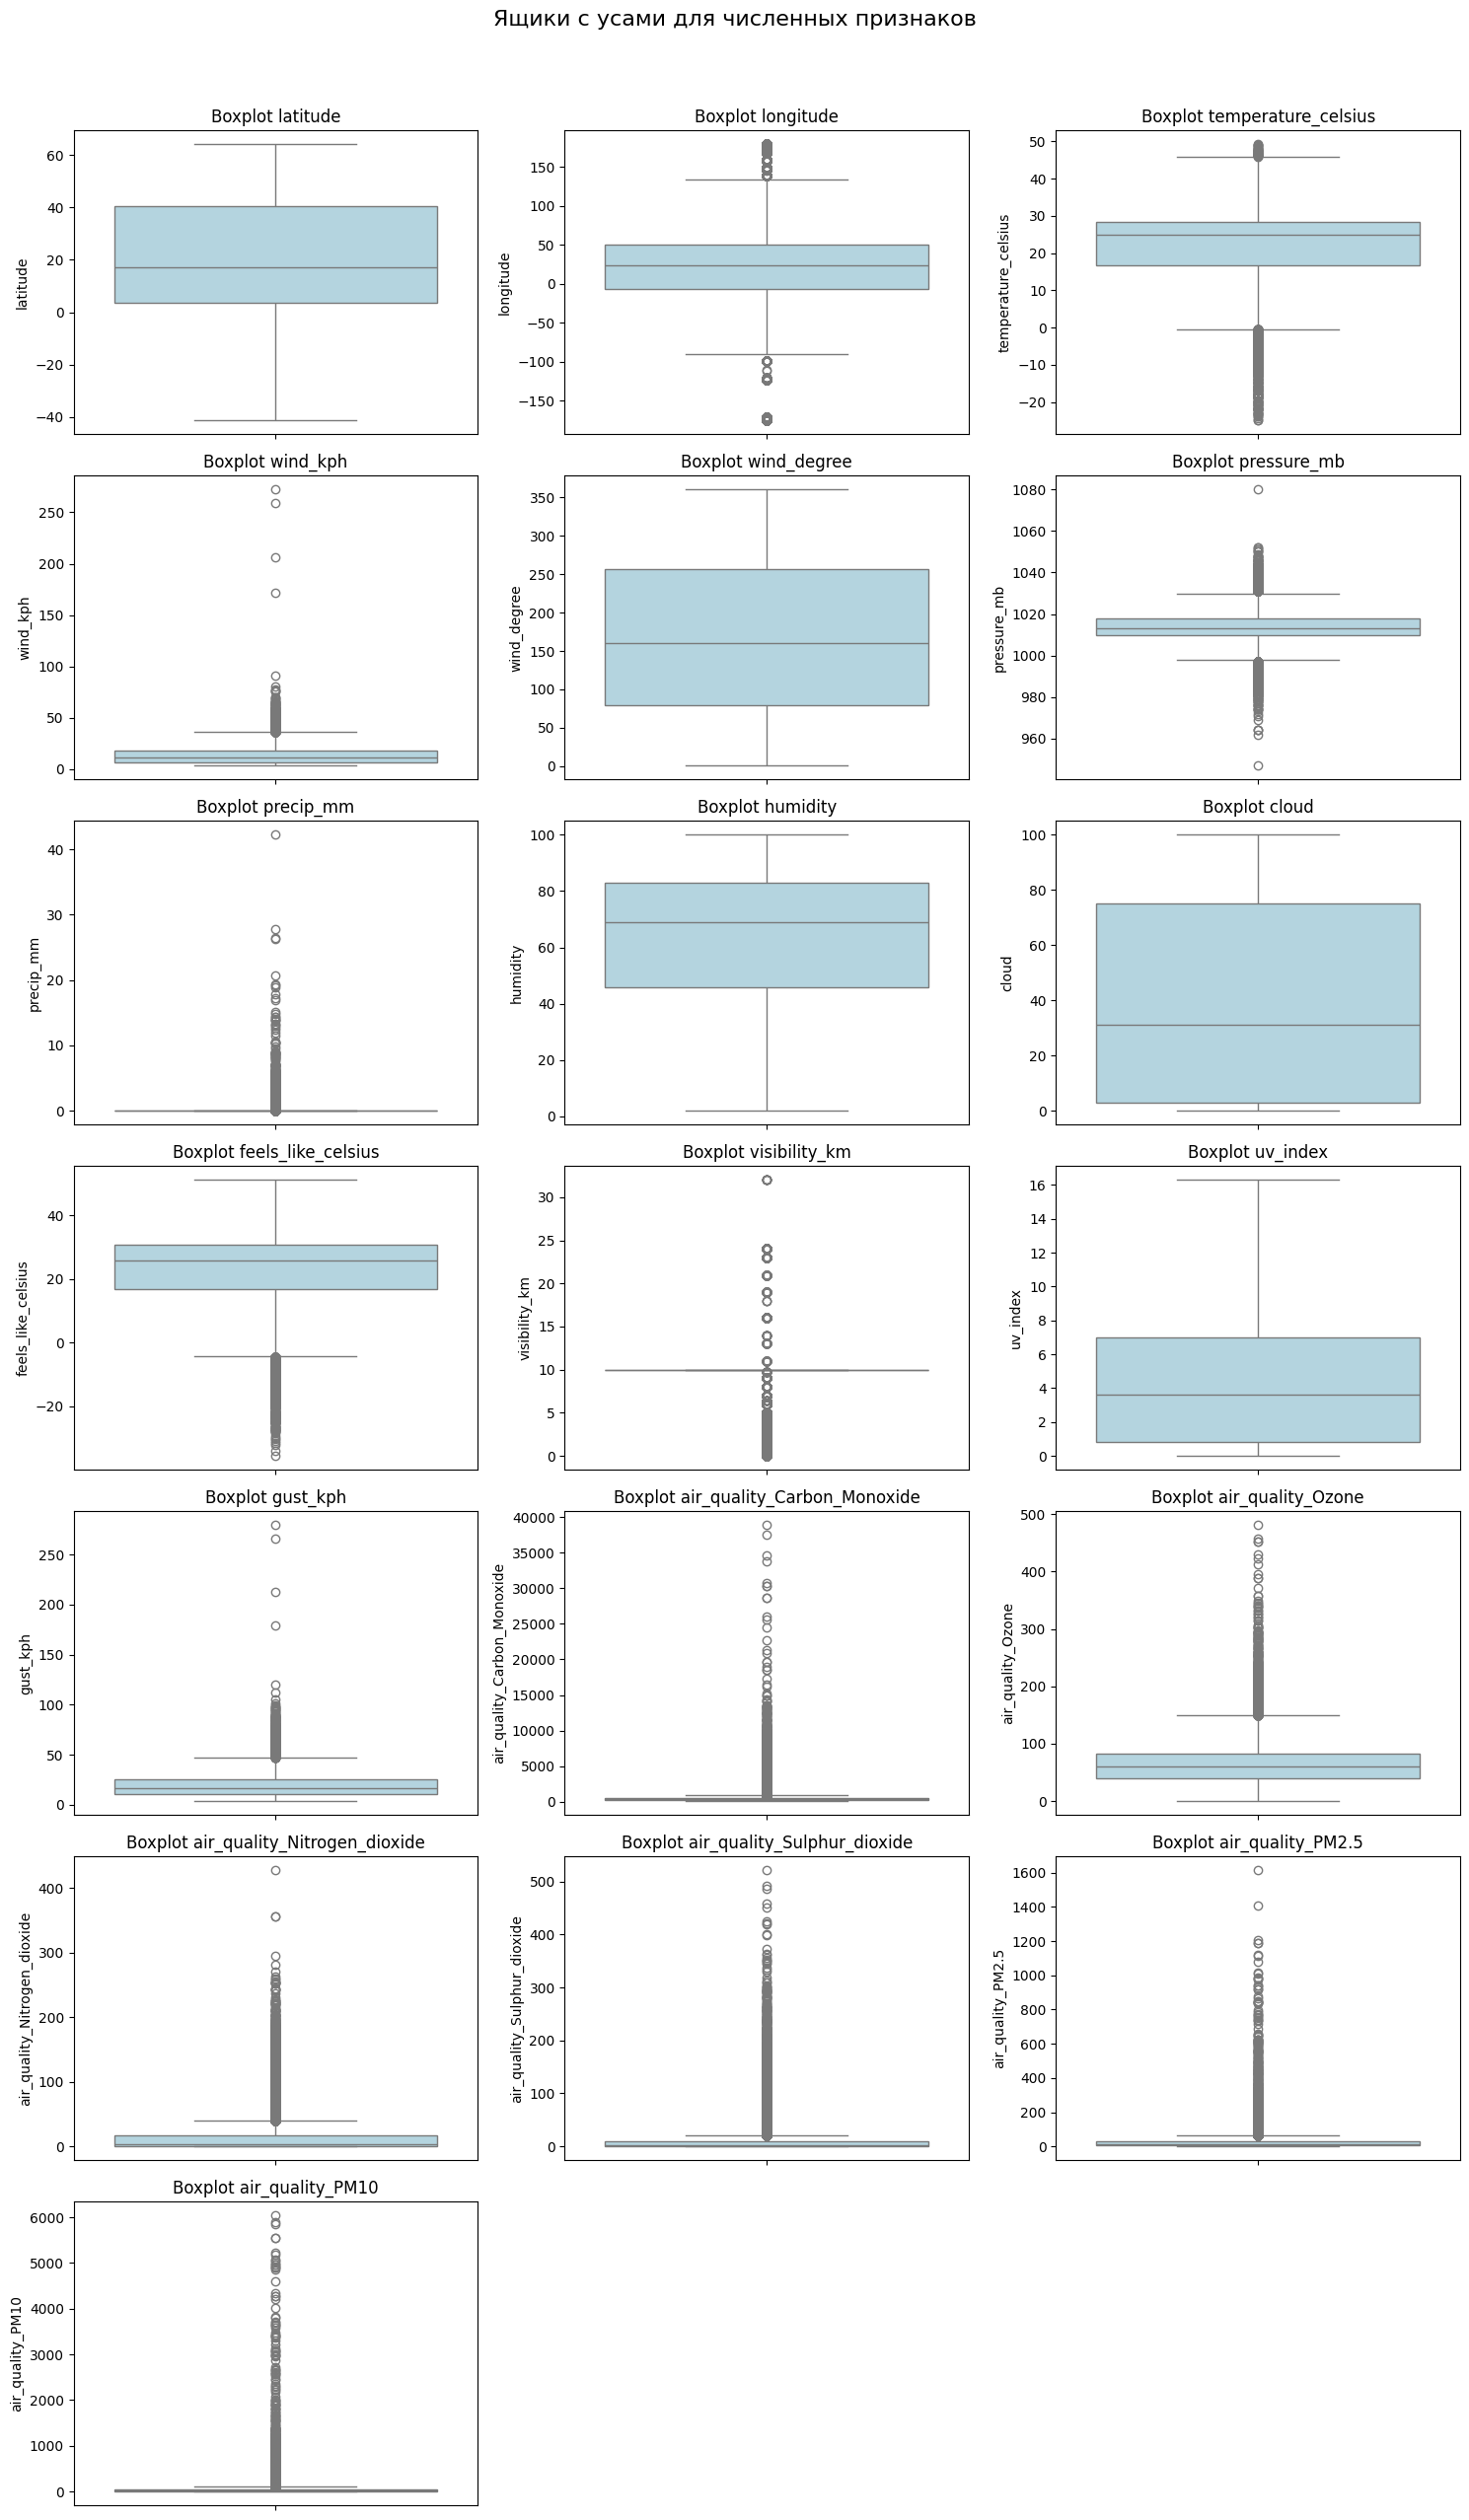

In [ ]:
plt.figure(figsize=(15, 25))
plt.suptitle('Ящики с усами для численных признаков', fontsize=16, y=1.02)
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(7, 3, i)
    sns.boxplot(y=data[column], color='lightblue')
    plt.title(f'Boxplot {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

Наличие большого количество выбросов конечно смущает, нужно подробнее в них разобраться. Для этого выведу данные в каких группах чаще всего встречаются аномальные значения и посмотрю может они отражают качество воздуха в крайних группах и не являются выбросами, а имеют большое значение

In [ ]:
outlier_columns = ['longitude', 'temperature_celsius', 'wind_kph', 'pressure_mb',
                   'precip_mm', 'feels_like_celsius', 'visibility_km', 'gust_kph',
                   'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
                   'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
                   'air_quality_PM2.5', 'air_quality_PM10']

def count_outliers_by_aqi(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    outlier_counts = outliers['air_quality_us-epa-index'].value_counts().sort_index()

    return outlier_counts.reindex(range(1, 7), fill_value=0)

outlier_distributions = {col: count_outliers_by_aqi(data, col) for col in outlier_columns}

for col, counts in outlier_distributions.items():
    print(f"\nРаспределение выбросов для {col}:")
    print(counts)


Распределение выбросов для longitude:
air_quality_us-epa-index
1    3719
2     668
3     141
4     147
5       2
6       0
Name: count, dtype: int64

Распределение выбросов для temperature_celsius:
air_quality_us-epa-index
1    545
2    449
3    170
4    136
5     17
6     12
Name: count, dtype: int64

Распределение выбросов для wind_kph:
air_quality_us-epa-index
1    701
2    141
3     26
4     40
5      9
6      1
Name: count, dtype: int64

Распределение выбросов для pressure_mb:
air_quality_us-epa-index
1    818
2    879
3    410
4    203
5     14
6      7
Name: count, dtype: int64

Распределение выбросов для precip_mm:
air_quality_us-epa-index
1    8029
2    2499
3     486
4     290
5      47
6      33
Name: count, dtype: int64

Распределение выбросов для feels_like_celsius:
air_quality_us-epa-index
1    544
2    396
3    120
4     91
5     11
6      6
Name: count, dtype: int64

Распределение выбросов для visibility_km:
air_quality_us-epa-index
1    5516
2    3140
3    1491
4    1

Для метеорологических признаков (wind_kph, gust_kph, precip_mm, visibility_km, pressure_mb, temperature_celsius, feels_like_celsius): Заменим выбросы в группах 2, 3, 4 на медианные значения в этих группах, оставив выбросы в группах 1, 5, 6. Это уменьшит шум в промежуточных классах, сохранив важные экстремальные значения.
Для загрязнителей (air_quality_Carbon_Monoxide, air_quality_Ozone, air_quality_Nitrogen_dioxide, air_quality_Sulphur_dioxide, air_quality_PM2.5, air_quality_PM10): Оставим выбросы во всех группах, так как они отражают реальные пики загрязнения, которые важны для классификации.
Для longitude: Выбросы связаны с географическим покрытием и не являются ошибками. Оставляем без изменений во всех группах.

In [ ]:
import pandas as pd
import numpy as np

meteo_columns = ['longitude', 'temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm',
                 'feels_like_celsius', 'visibility_km', 'gust_kph']

def replace_outliers_in_middle_groups(df, column, group_col='air_quality_us-epa-index'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    medians_by_aqi = df.groupby(group_col)[column].median()

    df_copy = df.copy()
    for aqi_value in [2, 3, 4]:
        group_mask = df_copy[group_col] == aqi_value
        condition = group_mask & ((df_copy[column] < lower_bound) | (df_copy[column] > upper_bound))
        df_copy.loc[condition, column] = medians_by_aqi[aqi_value]
    return df_copy

for col in meteo_columns:
    if col != 'longitude':
        data = replace_outliers_in_middle_groups(data, col)

def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers['air_quality_us-epa-index'].value_counts().sort_index().reindex(range(1, 7), fill_value=0)

for col in meteo_columns:
    print(f"\nРаспределение выбросов для {col} после замены в группах 2, 3, 4:")
    print(count_outliers(data, col))


Распределение выбросов для longitude после замены в группах 2, 3, 4:
air_quality_us-epa-index
1    3719
2     668
3     141
4     147
5       2
6       0
Name: count, dtype: int64

Распределение выбросов для temperature_celsius после замены в группах 2, 3, 4:
air_quality_us-epa-index
1    690
2    222
3     73
4     43
5     19
6     22
Name: count, dtype: int64

Распределение выбросов для wind_kph после замены в группах 2, 3, 4:
air_quality_us-epa-index
1    701
2      0
3      0
4      0
5      9
6      1
Name: count, dtype: int64

Распределение выбросов для pressure_mb после замены в группах 2, 3, 4:
air_quality_us-epa-index
1    1481
2     739
3     313
4     185
5      26
6      12
Name: count, dtype: int64

Распределение выбросов для precip_mm после замены в группах 2, 3, 4:
air_quality_us-epa-index
1    10665
2      962
3      185
4       92
5       63
6       49
Name: count, dtype: int64

Распределение выбросов для feels_like_celsius после замены в группах 2, 3, 4:
air_quality

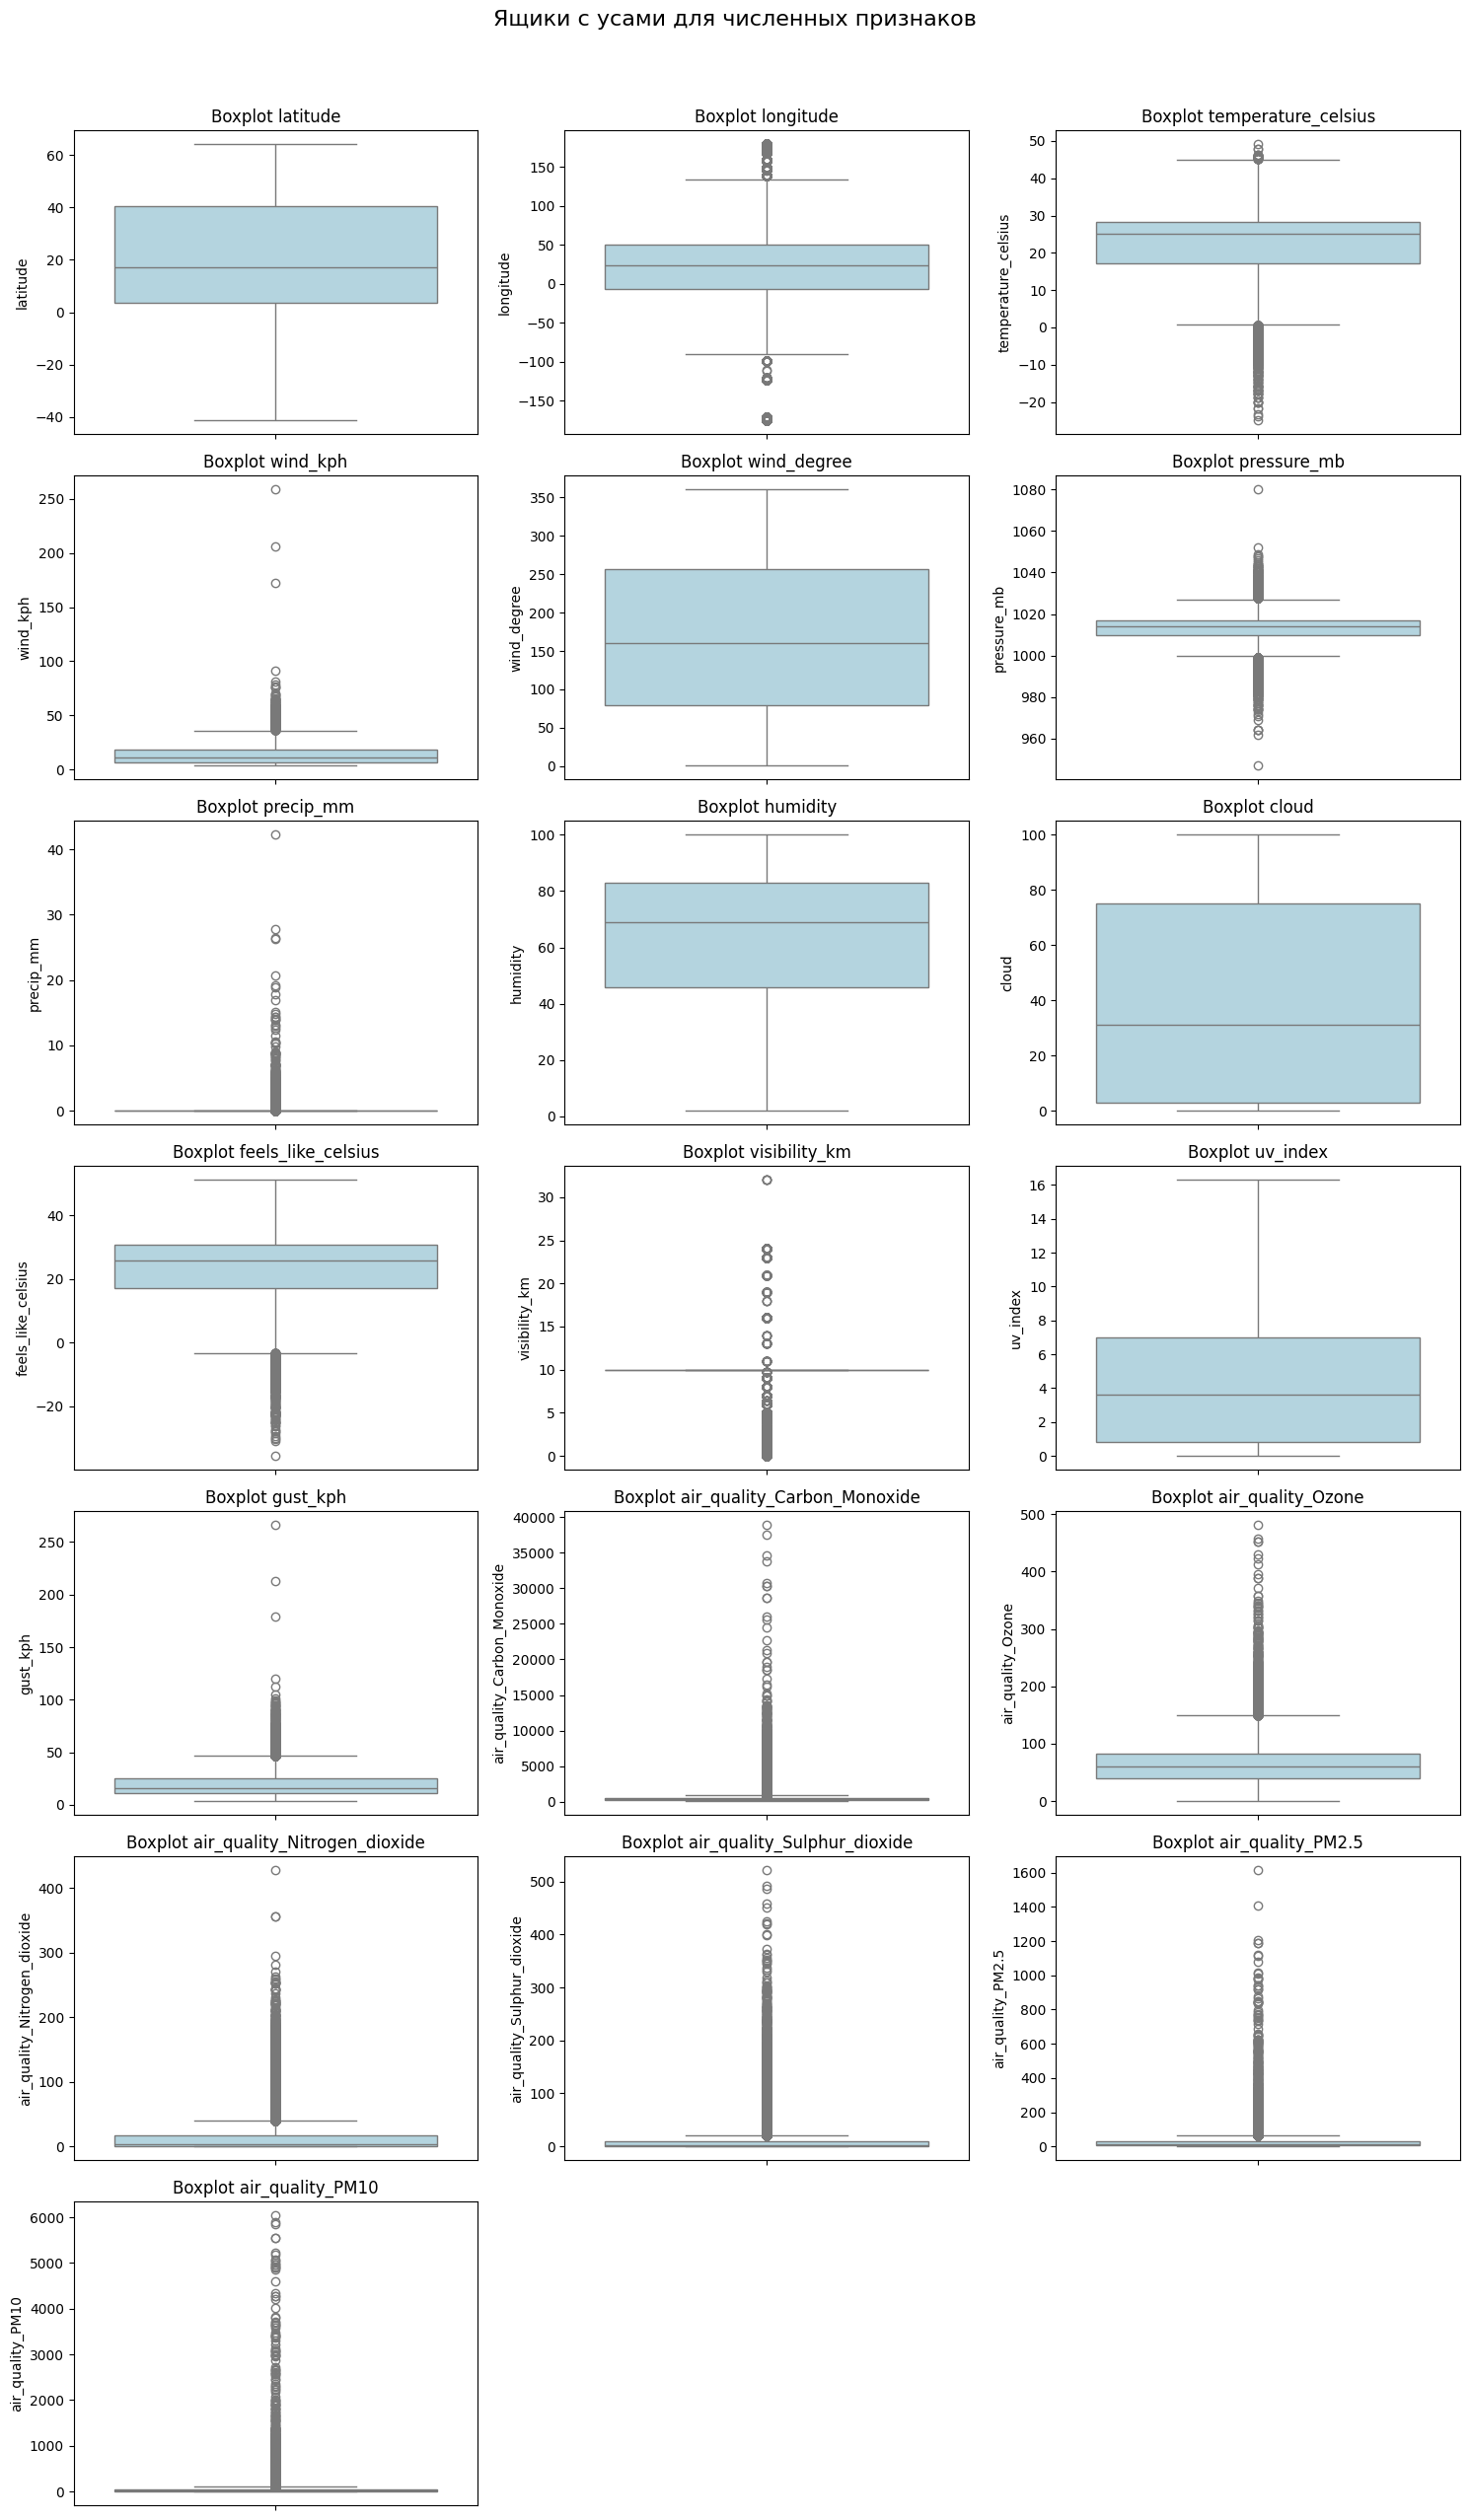

In [ ]:
plt.figure(figsize=(15, 25))
plt.suptitle('Ящики с усами для численных признаков', fontsize=16, y=1.02)
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(7, 3, i)
    sns.boxplot(y=data[column], color='lightblue')
    plt.title(f'Boxplot {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

Отлично, мы сократили количество выбросов, которые создавали шум. Теперь остались качественные значения.

## Предобработка категориальных признаков

Для начала переведу last_updated в формат datetime для удобства взаимодействия с датой и временем в дальнейшем при потребности

In [ ]:
data['last_updated'] = pd.to_datetime(data['last_updated'], format='%Y-%m-%d %H:%M')

**country**

<ipython-input-31-0e6fa8390d16>:7: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-31-0e6fa8390d16>:7: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


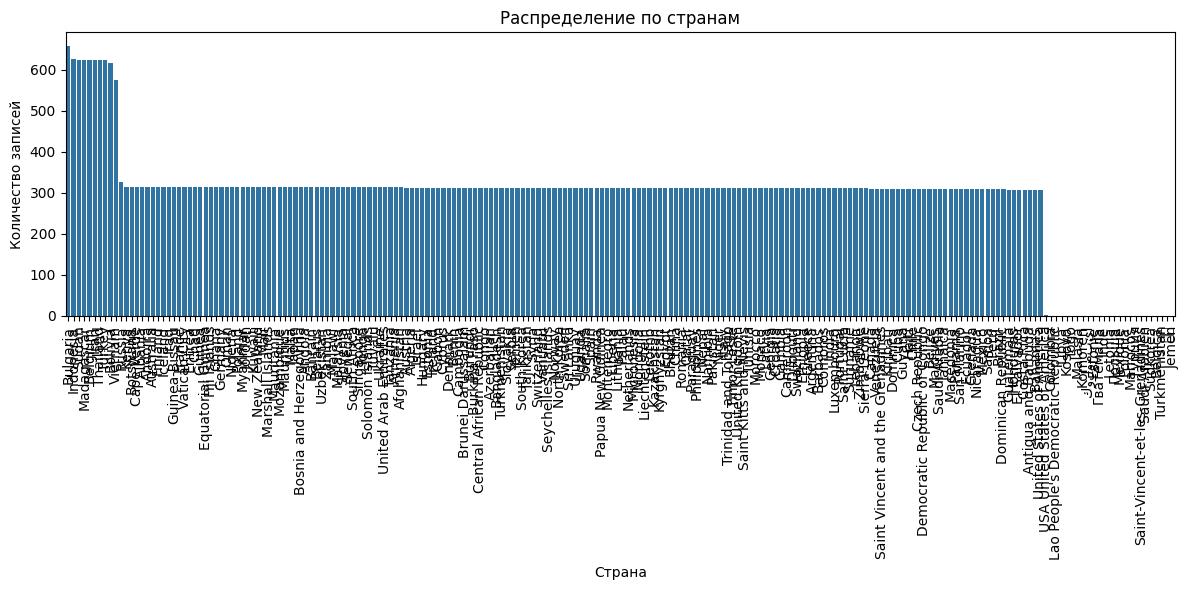

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='country', data=data, order=data['country'].value_counts().index)
plt.title('Распределение по странам')
plt.xlabel('Страна')
plt.ylabel('Количество записей')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
len(data['country'].unique())

210

In [ ]:
data['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Madagascar', 'Cape Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Comoros',
       'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus',
       'Czech Republic', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Swaziland', 'Ethiopia', 'Fiji Islands', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau

**Проблемы, выявленные в данных:**<br>
"United States of America" и "USA United States of America". Это, скорее всего, одно и то же, так как "USA" — сокращение для "United States of America".<br>
"Colombia" и "كولومبيا" (Colombia на арабском). Это дубликат, так как оба названия относятся к одной стране.<br>
"Malásia" вместо "Malaysia". Явная опечатка (лишний акцент на "a").<br>
"Kyrghyzstan" вместо "Kyrgyzstan". Опечатка в написании (лишняя "h").<br>
"Komoren" вместо "Comoros". Это немецкое название Коморских островов, но в датасете используется английский стандарт, так что это некорректно.<br>
"Estonie" (французское название Эстонии, должно быть "Estonia").<br>
"Гватемала" (русское название Гватемалы, должно быть "Guatemala").<br>
"Inde" (французское название Индии, должно быть "India").<br>
"Letonia" (испанское/португальское название Латвии, должно быть "Latvia").<br>
"Польша" (русское название Польши, должно быть "Poland").<br>
"Mexique" (французское название Мексики, должно быть "Mexico").<br>
"Polônia" (португальское название Польши, должно быть "Poland").<br>
"Marrocos" (португальское название Марокко, должно быть "Morocco").<br>
"Турция" (русское название Турции, должно быть "Turkey").<br>
"Saint-Vincent-et-les-Grenadines" (французское название, должно быть "Saint Vincent and the Grenadines").<br>
"Saudi Arabien" (немецкое/шведское написание, должно быть "Saudi Arabia").<br>
"Südkorea" (немецкое название Южной Кореи, должно быть "South Korea").<br>
"Bélgica" (испанское/португальское название Бельгии, должно быть "Belgium").<br>
"Turkménistan" (французское название Туркменистана, должно быть "Turkmenistan").<br>
"火鸡" (китайское название Турции, буквально "огненная птица", должно быть "Turkey").<br>
"Jemen" (немецкое/шведское название Йемена, должно быть "Yemen").<br>

In [ ]:
country_replacements = {
    'USA United States of America': 'United States of America',
    'كولومبيا': 'Colombia',
    'Malásia': 'Malaysia',
    'Kyrghyzstan': 'Kyrgyzstan',
    'Komoren': 'Comoros',
    'Estonie': 'Estonia',
    'Гватемала': 'Guatemala',
    'Inde': 'India',
    'Letonia': 'Latvia',
    'Польша': 'Poland',
    'Mexique': 'Mexico',
    'Polônia': 'Poland',
    'Marrocos': 'Morocco',
    'Турция': 'Turkey',
    'Saint-Vincent-et-les-Grenadines': 'Saint Vincent and the Grenadines',
    'Saudi Arabien': 'Saudi Arabia',
    'Südkorea': 'South Korea',
    'Bélgica': 'Belgium',
    'Turkménistan': 'Turkmenistan',
    '火鸡': 'Turkey',
    'Jemen': 'Yemen',
    'Fiji Islands': 'Fiji'
}

In [ ]:
data['country'] = data['country'].replace(country_replacements)

In [ ]:
data['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Madagascar', 'Cape Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Comoros',
       'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus',
       'Czech Republic', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Swaziland', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada',
       'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guya

В датасете используют устаревшие названия стран, поэтому заменю их на ностоящие:

In [ ]:
country_replacements = {
    'Swaziland': 'Eswatini',
    'Macedonia': 'North Macedonia',
    'Seychelles Islands': 'Seychelles',
    'Congo': 'Republic of Congo'
}
data['country'] = data['country'].replace(country_replacements)

Проверка количества уникальных стран после исправлений

In [ ]:
len(data['country'].unique())

190

Проверю есть ли страны с малым количеством записей

In [ ]:
data['country'].value_counts().tail(10)

,count
country,
Bahamas,308
Antigua and Barbuda,308
El Salvador,308
Costa Rica,308
Honduras,308
Colombia,2
Lao People's Democratic Republic,1
Libya,1
Kosovo,1


Да, явно видно, что страны: Colombia, Lao People's Democratic Republic, Libya, Kosovo, Togo имеют мало записей. Объединю их в одну категорю "Other". Так как такие редкие категории могут быть шумом или привести к переобучению.

In [ ]:
data['country'] = data['country'].replace(["Colombia", "Lao People's Democratic Republic", "Libya", "Kosovo", "Togo"], 'Other')

Проверка корректности координат:
Широта должна быть в диапазоне [-90, 90] (от Южного полюса до Северного).
Долгота должна быть в диапазоне [-180, 180] (от западной до восточной долготы).

In [ ]:
data[~data['latitude'].between(-90, 90) | ~data['longitude'].between(-180, 180)]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index


Таких значений не наблюдается, значит координаты корректны, но сейчас так же сверю координаты для каждой строны, чтобы не было ложной информации. Для этого выведу координаты по странам (мин/макс):

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
data.groupby('country')[['latitude', 'longitude']].agg(['min', 'max'])

latitude          longitude          
                                      min      max       min       max
country                                                               
Afghanistan                       34.5167  34.5200   69.1800   69.1833
Albania                           41.3275  41.3300   19.8189   19.8200
Algeria                           36.7600  36.7631    3.0500    3.0506
Andorra                           42.5000  42.5000    1.5167    1.5200
Angola                            -8.8400  -8.8383   13.2300   13.2344
Antigua and Barbuda               17.1167  17.1200  -61.8500  -61.8500
Argentina                        -34.5900 -34.5875  -58.6725  -58.6700
Armenia                           40.1800  40.1811   44.5100   44.5136
Australia                        -37.8200 -35.2800  144.9700  149.2200
Austria                           48.2000  48.2000   16.3667   16.3700
Azerbaijan                        40.3953  40.4000   49.8800   49.8822
Bahamas                           25.0800  25.0833  -77.3500  -77.3500
Bahrain                           26.2361  26.2400   50.5800   50.5831
Bangladesh                        23.7200  23.7231   90.4086   90.4100
Barbados                          13.1000  13.1000  -59.6200  -59.6167
Belarus                           53.9000  53.9000   27.5667   27.5700
Belgium                           50.8300  51.2500    2.9800    4.7500
Belize                            17.2500  17.2500  -88.7700  -88.7667
Benin                              6.4800   6.4833    2.6167    2.6200
Bhutan                            27.4800  27.4833   89.6000   89.6000
Bolivia                          -19.0431 -11.1800  -67.0833  -65.2592
Bosnia and Herzegovina            43.8500  43.8500   18.3800   18.3833
Botswana                         -24.6500 -24.6464   25.9100   25.9119
Brazil                           -23.5300  -2.0800  -58.1700  -46.6200
Brunei Darussalam                  4.8800   4.8833  114.9300  114.9333
Bulgaria                          42.6800  43.8100   23.2400   24.7000
Burkina Faso                      12.3700  12.3703   -1.5247   -1.5200
Burundi                           -3.3800  -3.3761   29.3600   29.3600
Cambodia                          11.5500  11.5500  104.9167  104.9200
Cameroon                           3.8700   7.3200    9.7000   13.5833
Canada                            45.4167  45.4200  -75.7000  -75.7000
Cape Verde                        14.9300  14.9315  -23.5125  -23.5100
Central African Republic           4.3667   4.3700   18.5800   18.5833
Chad                              12.1100  12.1131   15.0492   15.0500
Chile                            -33.4500 -33.4500  -70.6700  -70.6667
China                             39.9289  39.9300  116.3883  116.3900
Comoros                          -12.3500 -11.7000   43.2400   43.8500
Costa Rica                         9.8000   9.9700  -84.1700  -84.0800
Croatia                           45.8000  45.8000   16.0000   16.0000
Cuba                              23.1300  23.1319  -82.3642  -82.3600
Cyprus                            35.1667  35.1700   33.3667   33.3700
Czech Republic                    50.0800  50.0833   14.4667   14.4700
Democratic Republic of Congo      -4.3000  -4.3000   15.3000   15.3000
Denmark                           55.6667  55.6700   12.5800   12.5833
Djibouti                          11.5950  11.6000   43.1481   43.1500
Dominica                          15.3000  15.3000  -61.4000  -61.4000
Dominican Republic                18.4667  18.4700  -69.9000  -69.9000
Ecuador                           -0.2200  -0.2167  -78.5000  -78.5000
Egypt                             30.0500  30.0500   31.2500   31.2500
El Salvador                       13.7086  13.7100  -89.2031  -89.2000
Equatorial Guinea                  3.7500   3.7500    8.7800    8.7833
Eritrea                           15.3300  15.3333   38.9300   38.9333
Estonia                           59.4300  59.4339   24.7281   24.7300
Eswatini                         -26.3200 -26.3167   31.1

Все данные выглядят приемлимо, за исключением одной проблемы, о ней ниже. Так же хочется отметить, есть ряд стран с узким диапозоном координат (Россия, Китай, Бразилия, Австралия, Индия), значит данные представляют только часть территории. Например определенные города, а не все с территории страны.

Заметила подозрительные координаты в United States of America:<br>
Широта: min = 7.5000, max = 48.0800<br>
Долгота: min = -123.0439, max = 134.5700<br>
Проблема:<br>
Долгота max = 134.5700 подозрительна. Континентальная часть США находится в диапазоне долготы примерно [-125, -66], а Гавайи — около [-160, -154]. Значение 134.5700 (восточная долгота) находится в районе Тихого океана (например, около Микронезии или Японии), что не соответствует территории США.<br>
Широта min = 7.5000 также вызывает вопросы. Минимальная широта для США (Гавайи) — около 19. Значение 7.5 ближе к экватору (например, Колумбия или Венесуэла).

In [ ]:
suspicious_usa = data[(data['country'] == 'United States of America') &
                      ((data['longitude'] > -66) | (data['latitude'] < 19))]
print(suspicious_usa[['location_name', 'latitude', 'longitude']])

     location_name  latitude  longitude
8083         Palau       7.5     134.57


Возможно, Палау ошибочно указана страна 'United States of America'.

In [ ]:
print(data[data['location_name'] == 'Palau'][['country', 'latitude', 'longitude']])

                       country  latitude  longitude
8083  United States of America       7.5     134.57


Да, так и есть, исправим эту ошибку

In [ ]:
data.loc[data['location_name'] == 'Palau', 'country'] = 'Palau'

**location_name**

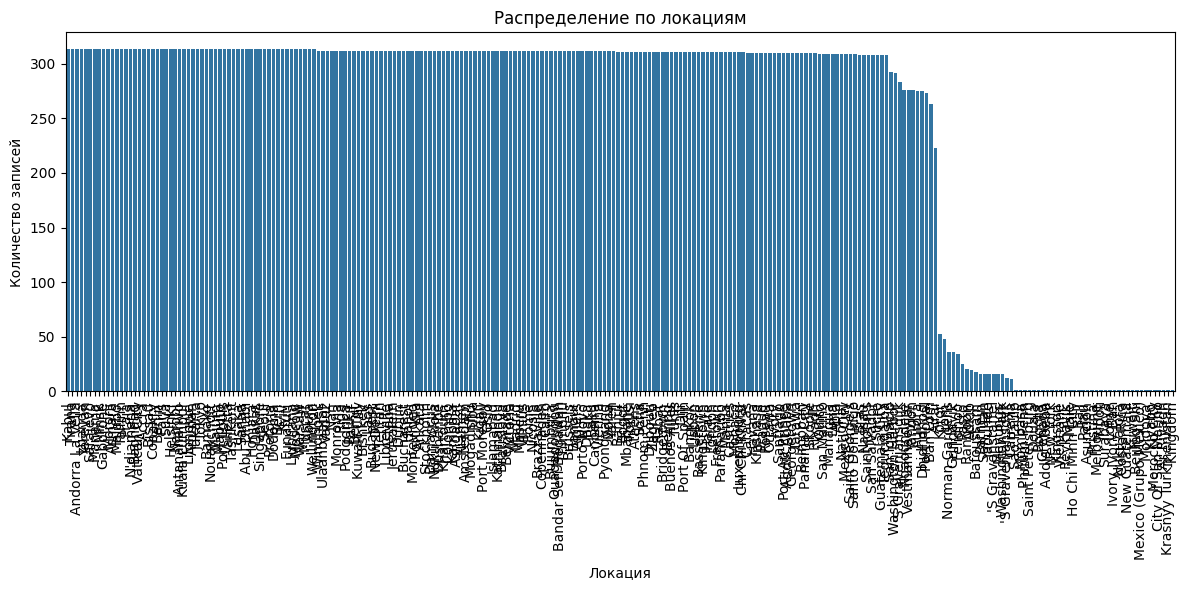

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='location_name', data=data, order=data['location_name'].value_counts().index)
plt.title('Распределение по локациям')
plt.xlabel('Локация')
plt.ylabel('Количество записей')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
len(data['location_name'].unique())

248

In [ ]:
data['location_name'].unique()

array(['Kabul', 'Tirana', 'Algiers', 'Andorra La Vella', 'Luanda',
       "Saint John's", 'Buenos Aires', 'Yerevan', 'Canberra', 'Vienna',
       'Baku', 'Nassau', 'Manama', 'Dhaka', 'Bridgetown', 'Minsk',
       'Brussels', 'Belmopan', 'Porto-Novo', 'Thimphu', 'Sucre',
       'Sarajevo', 'Gaborone', 'Bras', 'Bandar Seri Begawan', 'Sofia',
       'Ouagadougou', 'Bujumbura', 'Ivory', 'Praia', 'Phnom Penh',
       'Yaounde', 'Ottawa', 'Bangui', "N'djamena", 'Santiago', 'Beijing',
       'Bogot', 'Moroni', 'Brazzaville', 'San Juan', 'Zagreb', 'Havana',
       'Nicosia', 'Prague', 'Kinshasa', 'Copenhagen', 'Djibouti',
       'Roseau', 'Santo Domingo', 'Quito', 'Cairo', 'San Salvador',
       'Malabo', 'Asmara', 'Tallinn', 'Mbabane', 'Addis Ababa', 'Suva',
       'Helsinki', 'Paris', 'Libreville', 'Banjul', 'Tbilisi', 'Berlin',
       'Accra', 'Athens', "Saint George's", 'Guatemala City', 'Conakry',
       'Bissau', 'Georgetown', 'Port-Au-Prince', 'Vatican City',
       'Tegucigalpa', 'Buda

*Дубликаты или схожие названия:*<br>
**Beijing и Beijing Shi:**<br>
"Beijing Shi" — это, вероятно, китайское название Пекина (Beijing), где "Shi" означает "город". Это дубликат.<br>
**Guatemala City и New Guatemala:**<br>
"New Guatemala" — это, скорее всего, опечатка или альтернативное название для Guatemala City (официальное название столицы Гватемалы).<br>
**'S Gravenstaffel, 'S Gravenjansdijk, 'S Gravenjansdyk:**<br>
Эти названия похожи и, вероятно, относятся к одному месту в Нидерландах (возможно, к району или городу с похожим названием). Различия в написании ('s вместо 'S, dyjk/dyk) указывают на опечатки.<br>
**Ivory и Ivory Ivory Ban:**<br>
"Ivory" — это, вероятно, сокращение или ошибка для Кот-д’Ивуара (Côte d'Ivoire). "Ivory Ivory Ban" выглядит как некорректное название.<br>
*Опечатки или некорректные названия:*<br>
**Bras:**<br>
Похоже на сокращение или опечатку для "Brasília" (столица Бразилии).<br>
**Laos:**<br>
Название страны, а не города. Должно быть, например, "Vientiane" (столица Лаоса).<br>
**National:**<br>
Неясное название, возможно, ошибка. Может относиться к "National Capital" (например, Вашингтон для США или Канберра для Австралии).<br>
**Mexico (Grupo Mexico):**<br>
"Grupo Mexico" — это, вероятно, название компании, а не города. Должно быть "Mexico City".<br>
**Morocco City:**<br>
В Марокко нет города с названием "Morocco City". Вероятно, имеется в виду "Rabat" или "Casablanca".<br>
**Krasnyy Turkmenistan:**<br>
"Krasnyy" (красный) — это не город в Туркменистане. Возможно, ошибка или устаревшее название. Должно быть "Ashgabat".<br>
**-Kingdom:**<br>
Некорректное название, возможно, ошибка ввода. Может относиться к United Kingdom (например, London).<br>
**Kiyabo:**<br>
Неизвестное название, не соответствует известным городам. Возможно, опечатка.<br>
*Названия, требующие проверки соответствия стране:*<br>
**Aurora:**<br>
Может относиться к городу в США (например, Aurora, Colorado) или другим странам (например, Филиппины). Нужно проверить страну.<br>
**Adkip, Carreria, Chi Chi Khvar:**<br>
Неизвестные названия, возможно, опечатки или вымышленные локации.<br>
**Ar Riyadh:**<br>
Это арабское написание для "Riyadh" (Эр-Рияд, Саудовская Аравия). В датасете уже есть "Riyadh".<br>

Явные дубликаты сразу заменю

In [ ]:
location_replacements = {
    'Beijing Shi': 'Beijing',
    'New Guatemala': 'Guatemala City',
    "'S Gravenstaffel": "'s-Gravenzande",
    "'S Gravenjansdijk": "'s-Gravenzande",
    "'S Gravenjansdyk": "'s-Gravenzande",
    'Ivory': 'Yamoussoukro',
    'Ivory Ivory Ban': 'Yamoussoukro',
    'Bras': 'Brasília',
    'Laos': 'Vientiane',
    'Mexico (Grupo Mexico)': 'Mexico City',
    'Morocco City': 'Rabat',
    'Krasnyy Turkmenistan': 'Ashgabat',
    'Ar Riyadh': 'Riyadh'
}
data['location_name'] = data['location_name'].replace(location_replacements)

Для остальных произведу более детальную проверку:

In [ ]:
suspicious_locations = ['Aurora', 'Adkip', 'Carreria', 'Chi Chi Khvar', 'National', '-Kingdom', 'Kiyabo']
suspicious_data = data[data['location_name'].isin(suspicious_locations)][['country', 'location_name', 'latitude', 'longitude']]
print(suspicious_data)

           country  location_name  latitude  longitude
112           Iran  Chi Chi Khvar   36.2600    46.5900
133        Bolivia       National  -11.1800   -67.0800
307           Iran  Chi Chi Khvar   36.2600    46.5900
328        Bolivia       National  -11.1800   -67.0800
502           Iran  Chi Chi Khvar   36.2600    46.5900
522        Bolivia       National  -11.1800   -67.0800
694           Iran  Chi Chi Khvar   36.2600    46.5900
715        Bolivia       National  -11.1800   -67.0800
888           Iran  Chi Chi Khvar   36.2600    46.5900
909        Bolivia       National  -11.1800   -67.0800
1083          Iran  Chi Chi Khvar   36.2600    46.5900
1104       Bolivia       National  -11.1800   -67.0800
1278          Iran  Chi Chi Khvar   36.2600    46.5900
1299       Bolivia       National  -11.1800   -67.0800
1473          Iran  Chi Chi Khvar   36.2600    46.5900
1494       Bolivia       National  -11.1800   -67.0800
1668          Iran  Chi Chi Khvar   36.2600    46.5900
1689      

После анализа данных, установиласта, что:<br>
Aurora (Парагвай, -23.43, -61.33) не соответствует известным городам. Замененю на "Other".<br>
Adkip (Палау, 7.36, 134.51) соответствует Корору. Замененю на "Koror".<br>
Carreria (Парагвай, -21.55, -58.12) не идентифицирована как город. Замененю на "Other".<br>
Chi Chi Khvar (Иран, 36.26, 46.59) близка к городу Саккез. Замененю на "Saqqez".<br>
National (Боливия, -11.18, -67.08) соответствует городу Кобиха. Замененю на "Cobija".<br>
-Kingdom (Турция, 38.85, 34.65) близка к Невшехиру. Замененю на "Nevsehir".<br>
Kiyabo (Филиппины, 14.60, 120.98) соответствует Маниле. Замененю на "Manila".<br>

In [ ]:
suspicious_replacements = {
    'Aurora': 'Other',
    'Adkip': 'Koror',
    'Carreria': 'Other',
    'Chi Chi Khvar': 'Saqqez',
    'National': 'Cobija',
    '-Kingdom': 'Nevsehir',
    'Kiyabo': 'Manila'
}

In [ ]:
data['location_name'] = data['location_name'].replace(suspicious_replacements)

In [ ]:
data['location_name'].value_counts().tail(30)

,count
location_name,
Pathein,16
Meyungs,16
Washington Park,16
Saint Petersburg,1
Mombasa,1
Sao Paulo,1
Douala,1
Bogota,1
Addis Abeba,1


Наблюдаем 27 редких локации с 1 записью. Объединеню в категорию "Other", что сократит количество уникальных значений и упростит данные для дальнейшего анализа.

In [ ]:
rare_locations = data['location_name'].value_counts()[data['location_name'].value_counts() == 1]

In [ ]:
len(rare_locations)

27

In [ ]:
data['location_name'] = data['location_name'].replace(rare_locations.index, 'Other')

In [ ]:
len(data['location_name'].unique())

208

**timezone**

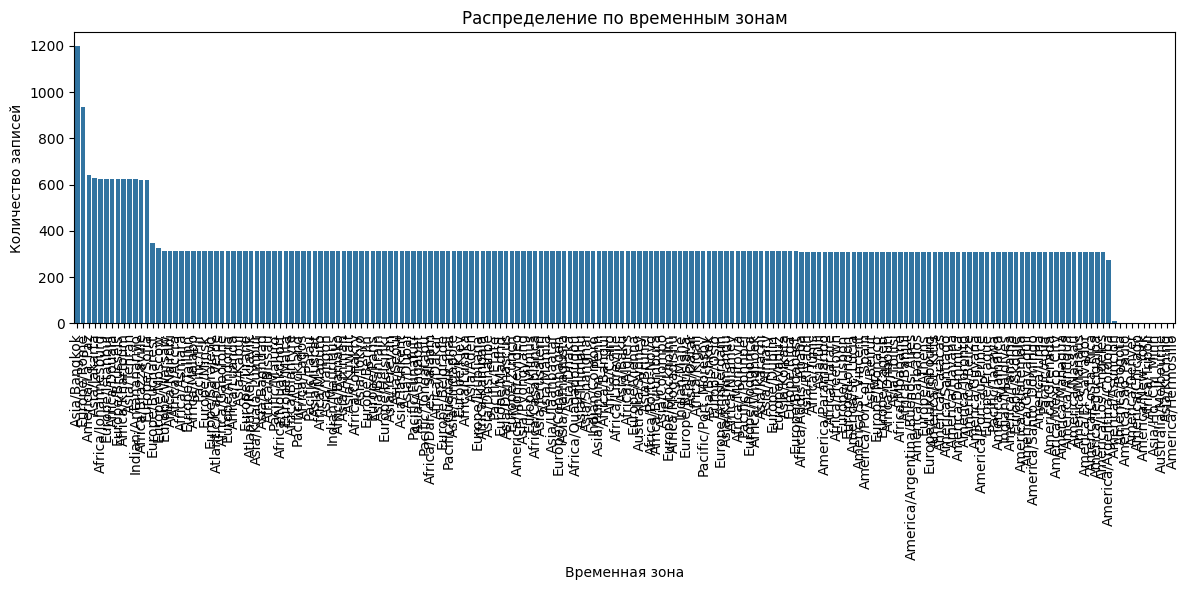

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='timezone', data=data, order=data['timezone'].value_counts().index)
plt.title('Распределение по временным зонам')
plt.xlabel('Временная зона')
plt.ylabel('Количество записей')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
len(data['timezone'].unique())

190

In [ ]:
data['timezone'].unique()

array(['Asia/Kabul', 'Europe/Tirane', 'Africa/Algiers', 'Europe/Andorra',
       'Africa/Luanda', 'America/Antigua',
       'America/Argentina/Buenos_Aires', 'Asia/Yerevan',
       'Australia/Sydney', 'Europe/Vienna', 'Asia/Baku', 'America/Nassau',
       'Asia/Bahrain', 'Asia/Dhaka', 'America/Barbados', 'Europe/Minsk',
       'Europe/Brussels', 'America/Belize', 'Africa/Porto-Novo',
       'Asia/Thimphu', 'America/La_Paz', 'Europe/Sarajevo',
       'Africa/Gaborone', 'America/Manaus', 'Asia/Brunei', 'Europe/Sofia',
       'Africa/Ouagadougou', 'Africa/Bujumbura', 'Indian/Antananarivo',
       'Atlantic/Cape_Verde', 'Asia/Phnom_Penh', 'Africa/Douala',
       'America/Toronto', 'Africa/Bangui', 'America/Santiago',
       'Asia/Shanghai', 'Indian/Comoro', 'Africa/Brazzaville',
       'America/Costa_Rica', 'Europe/Zagreb', 'America/Havana',
       'Asia/Famagusta', 'Europe/Prague', 'Europe/Copenhagen',
       'Africa/Djibouti', 'America/Dominica', 'America/Santo_Domingo',
       'America/

Проверю соответствия timezone, country и location_name. Потому что некоторые временные зоны могут не соответствовать указанным странам или городам.

In [ ]:
data[['country', 'location_name', 'timezone']].drop_duplicates().sort_values(by='country')

,country,location_name,timezone
0,Afghanistan,Kabul,Asia/Kabul
1,Albania,Tirana,Europe/Tirane
2,Algeria,Algiers,Africa/Algiers
3,Andorra,Andorra La Vella,Europe/Andorra
4,Angola,Luanda,Africa/Luanda
5,Antigua and Barbuda,Saint John's,America/Antigua
6,Argentina,Buenos Aires,America/Argentina/Buenos_Aires
7,Armenia,Yerevan,Asia/Yerevan
8,Australia,Canberra,Australia/Sydney
8103,Australia,Other,Australia/Melbourne


Проанализировав данные выявленны следующие несоответствия:<br>
Для Brasília (Бразилия) временная зона America/Manaus. Замененю на America/Sao_Paulo.<br>
Для Washington Park и Washington Harbor (США) временная зона America/Los_Angeles. Замененю на America/New_York, так как они находятся на восточном побережье.<br>
Для Moroni (США) исправлю страну на Comoros и временную зону на Indian/Comoro.<br>
Для Yamoussoukro (Мадагаскар и Малайзия) исправлю страну на Côte d'Ivoire и временную зону на Africa/Abidjan.<br>
Для Vientiane (Индонезия и Other) исправлю страну на Laos и временную зона на Asia/Vientiane.<br>
Для Beirut (Польша) исправлю страну на Lebanon и временную зону на Asia/Beirut.<br>
Для Yaren (Турция) исправлю страну на Nauru и временную зону на Pacific/Nauru.<br>
Для Bern (Бельгия) исправлю страну на Switzerland и временную зону на Europe/Zurich.<br>
Для 's-Gravenzande (Бельгия) исправлю страну на Netherlands и временную зону на Europe/Amsterdam.<br>
Для Bogot (Болгария) исправлю страна на Colombia и временную зону на America/Bogota.<br>
Для Lom (Болгария) исправлю временную зону на Europe/Sofia, а для Lom исправлю страну на Bulgaria.<br>
Для Mexico City (Мексика) временную зону America/Hermosillo замененю на America/Mexico_City.<br>

In [ ]:
corrections = [
    # Бразилия
    ((data['location_name'] == 'Brasília') & (data['timezone'] == 'America/Manaus'),
     {'timezone': 'America/Sao_Paulo'}),

    # США
    ((data['location_name'] == 'Washington Park') & (data['timezone'] == 'America/Los_Angeles'),
     {'timezone': 'America/New_York'}),
    ((data['location_name'] == 'Washington Harbor') & (data['timezone'] == 'America/Los_Angeles'),
     {'timezone': 'America/New_York'}),
    ((data['location_name'] == 'Moroni') & (data['country'] == 'United States of America'),
     {'country': 'Comoros', 'timezone': 'Indian/Comoro'}),

    # Мадагаскар
    ((data['location_name'] == 'Yamoussoukro') & (data['country'] == 'Madagascar'),
     {'country': "Côte d'Ivoire", 'timezone': 'Africa/Abidjan'}),

    # Малайзия
    ((data['location_name'] == 'Yamoussoukro') & (data['country'] == 'Malaysia'),
     {'country': "Côte d'Ivoire", 'timezone': 'Africa/Abidjan'}),

    # Индонезия
    ((data['location_name'] == 'Vientiane') & (data['country'] == 'Indonesia'),
     {'country': 'Laos', 'timezone': 'Asia/Vientiane'}),

    # Польша
    ((data['location_name'] == 'Beirut') & (data['country'] == 'Poland'),
     {'country': 'Lebanon', 'timezone': 'Asia/Beirut'}),

    # Турция
    ((data['location_name'] == 'Yaren') & (data['country'] == 'Turkey'),
     {'country': 'Nauru', 'timezone': 'Pacific/Nauru'}),

    # Вьетнам
    ((data['location_name'] == 'Ban Lom') & (data['country'] == 'Vietnam'),
     {'timezone': 'Asia/Ho_Chi_Minh'}),

    # Бельгия
    ((data['location_name'] == 'Bern') & (data['country'] == 'Belgium'),
     {'country': 'Switzerland', 'timezone': 'Europe/Zurich'}),
    ((data['location_name'] == "'s-Gravenzande") & (data['country'] == 'Belgium'),
     {'country': 'Netherlands', 'timezone': 'Europe/Amsterdam'}),

    # Болгария
    ((data['location_name'] == 'Bogot') & (data['country'] == 'Bulgaria'),
     {'country': 'Colombia', 'timezone': 'America/Bogota'}),
    ((data['location_name'] == 'Lom') & (data['country'] == 'Bulgaria') & (data['timezone'] == 'Europe/Bucharest'),
     {'timezone': 'Europe/Sofia'}),

    # Россия
    ((data['location_name'] == 'Lom') & (data['country'] == 'Russia'),
     {'country': 'Bulgaria', 'timezone': 'Europe/Sofia'}),

    # Мексика
    ((data['location_name'] == 'Mexico City') & (data['timezone'] == 'America/Hermosillo'),
     {'timezone': 'America/Mexico_City'}),
]
for condition, updates in corrections:
    data.loc[condition, list(updates.keys())] = list(updates.values())

Проверю есть ли редкие временные зоны, чтобы сократить количество уникальных значений и упростить данные для моделирования.

In [ ]:
data['location_name'].value_counts().tail(10)

,count
location_name,
Grindavik,36
Felidhoo,34
Pasto,25
Rangoon,21
Bafoussam,18
San Juan,16
Yaounde,16
Pathein,16
Meyungs,16


Нет, редких зон не наблюдаю

**condition_text**

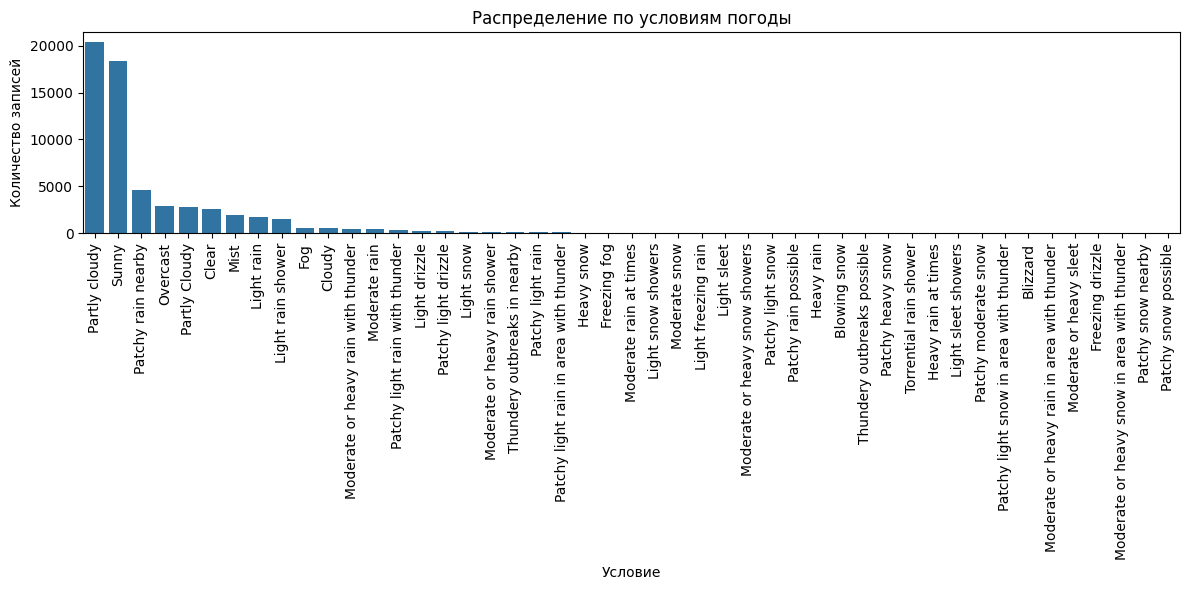

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='condition_text', data=data, order=data['condition_text'].value_counts().index)
plt.title('Распределение по условиям погоды')
plt.xlabel('Условие')
plt.ylabel('Количество записей')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
len(data['condition_text'].unique())

47

In [ ]:
data['condition_text'].unique()

array(['Partly Cloudy', 'Partly cloudy', 'Sunny', 'Light drizzle',
       'Clear', 'Overcast', 'Moderate or heavy rain with thunder',
       'Patchy light rain in area with thunder', 'Fog',
       'Patchy light rain with thunder', 'Patchy rain nearby',
       'Light rain', 'Mist', 'Cloudy', 'Thundery outbreaks in nearby',
       'Moderate rain', 'Light rain shower', 'Moderate rain at times',
       'Moderate or heavy rain shower', 'Heavy rain at times',
       'Patchy light rain', 'Patchy light drizzle',
       'Thundery outbreaks possible', 'Patchy rain possible',
       'Moderate or heavy rain in area with thunder', 'Heavy rain',
       'Torrential rain shower', 'Freezing fog',
       'Moderate or heavy snow showers', 'Light sleet', 'Blizzard',
       'Moderate snow', 'Light snow', 'Light sleet showers',
       'Light freezing rain', 'Heavy snow', 'Blowing snow',
       'Patchy heavy snow', 'Light snow showers',
       'Moderate or heavy sleet', 'Patchy light snow',
       'Patchy mo

Приведу к нижнему регистру, для избавления от явных дубликатов

In [ ]:
data['condition_text'] = data['condition_text'].str.lower()
len(data['condition_text'].unique())

46

Объеденю очень похожие категории

**patchy light rain in area with thunder → patchy light rain with thunder**<br>
Упрощение формулировки без потери смысла (гроза с локальным дождём).<br>
**moderate or heavy rain in area with thunder → moderate or heavy rain with thunder**<br>
Аналогично: удаление избыточного "in area" для единообразия.<br>
**patchy rain nearby → patchy rain possible**<br>
Стандартизация: "nearby" и "possible" в данном контексте означают вероятность осадков.<br>
**patchy snow nearby → patchy snow possible**<br>
Приведение к аналогичному с дождём формату (patchy rain possible).<br>
**moderate rain at times → moderate rain**<br>
"At times" не меняет интенсивность, только указывает на периодичность — это избыточно для категории.<br>
**heavy rain at times → heavy rain**<br>
Аналогично: интенсивность важнее временного характера.<br>
**torrential rain shower → heavy rain**<br>
"Ливневый дождь" является подкатегорией сильного дождя.<br>
**patchy light snow in area with thunder → patchy light rain with thunder**<br>
Гроза со снегом крайне редка — логичнее отнести к грозовому дождю.<br>
**moderate or heavy snow in area with thunder → moderate or heavy rain with thunder**<br>
Снег с грозой встречается редко, заменяем на более распространённую категорию дождя.<br>
**light sleet showers → light sleet**<br>
"Showers" (ливни) для мокрого снега избыточно — объединяем с общей категорией.<br>
**moderate or heavy sleet → moderate snow**<br>
Мокрый снег средней интенсивности ближе к снегу, чем к дождю.<br>
**blizzard → heavy snow**<br>
Метель — частный случай сильного снегопада с ветром.<br>
**freezing drizzle → light freezing rain**<br>
Ледяная морось и переохлаждённый дождь схожи по воздействию.<br>
**patchy moderate snow → moderate snow**<br>
Локальность ("patchy") не критична для умеренного снега.<br>
**patchy snow possible → light snow**<br>
"Возможность снега" при малом количестве случаев ≈ "лёгкий снег".

In [ ]:
condition_mappings = {
    'partly cloudy': 'partly cloudy',
    'patchy light rain in area with thunder': 'patchy light rain with thunder',
    'moderate or heavy rain in area with thunder': 'moderate or heavy rain with thunder',
    'patchy rain nearby': 'patchy rain possible',
    'patchy snow nearby': 'patchy snow possible',
    'moderate rain at times': 'moderate rain',
    'heavy rain at times': 'heavy rain',
    'torrential rain shower': 'heavy rain',
    'patchy light snow in area with thunder': 'patchy light rain with thunder',
    'moderate or heavy snow in area with thunder': 'moderate or heavy rain with thunder',
    'light sleet showers': 'light sleet',
    'moderate or heavy sleet': 'moderate snow',
    'blizzard': 'heavy snow',
    'freezing drizzle': 'light freezing rain',
    'patchy moderate snow': 'moderate snow',
    'patchy snow possible': 'light snow'
}

data['condition_text'] = data['condition_text'].replace(condition_mappings)

In [ ]:
data['condition_text'].value_counts()

,count
condition_text,
partly cloudy,23164
sunny,18406
patchy rain possible,4678
overcast,2891
clear,2623
mist,1946
light rain,1704
light rain shower,1538
fog,548


Отлично, теперь все категории без повторений и всех достаточное количество.

**wind_direction**

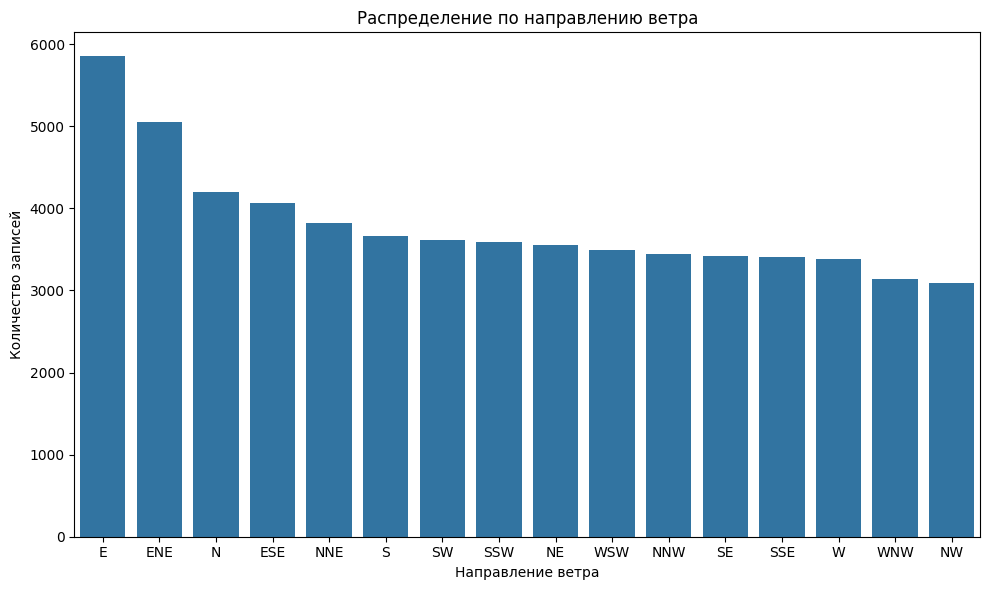

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='wind_direction', data=data, order=data['wind_direction'].value_counts().index)
plt.title('Распределение по направлению ветра')
plt.xlabel('Направление ветра')
plt.ylabel('Количество записей')
plt.tight_layout()
plt.show()

In [ ]:
len(data['wind_direction'].unique())

16

In [ ]:
data['wind_direction'].unique()

array(['NNW', 'NW', 'W', 'SW', 'SSE', 'E', 'N', 'SE', 'ESE', 'NNE', 'S',
       'WSW', 'SSW', 'ENE', 'NE', 'WNW'], dtype=object)

*Основные 4 направления:*<br>
N = Северный (North)<br>
E = Восточный (East)<br>
S = Южный (South)<br>
W = Западный (West)<br>
*Промежуточные направления(румбы):*<br>
NE = Северо-восточный (North-East)<br>
SE = Юго-восточный (South-East)<br>
SW = Юго-западный (South-West)<br>
NW = Северо-западный (North-West)<br>
*Уточнённые румбы (добавляется "тень" от основного направления):*<br>
NNE = Северо-северо-восточный (North-North-East)<br>
ENE = Восточно-северо-восточный (East-North-East)<br>
ESE = Восточно-юго-восточный (East-South-East)<br>
SSE = Юго-юго-восточный (South-South-East)<br>
SSW = Юго-юго-западный (South-South-West)<br>
WSW = Западно-юго-западный (West-South-West)<br>
WNW = Западно-северо-западный (West-North-West)<br>
NNW = Северо-северо-западный (North-North-West)<br>

In [ ]:
data['wind_direction'].value_counts()

,count
wind_direction,
E,5851
ENE,5054
N,4203
ESE,4060
NNE,3818
S,3668
SW,3619
SSW,3585
NE,3553


В этом признаке все отлично, повторений нет, все значения понятны

## Построение коррелограмм

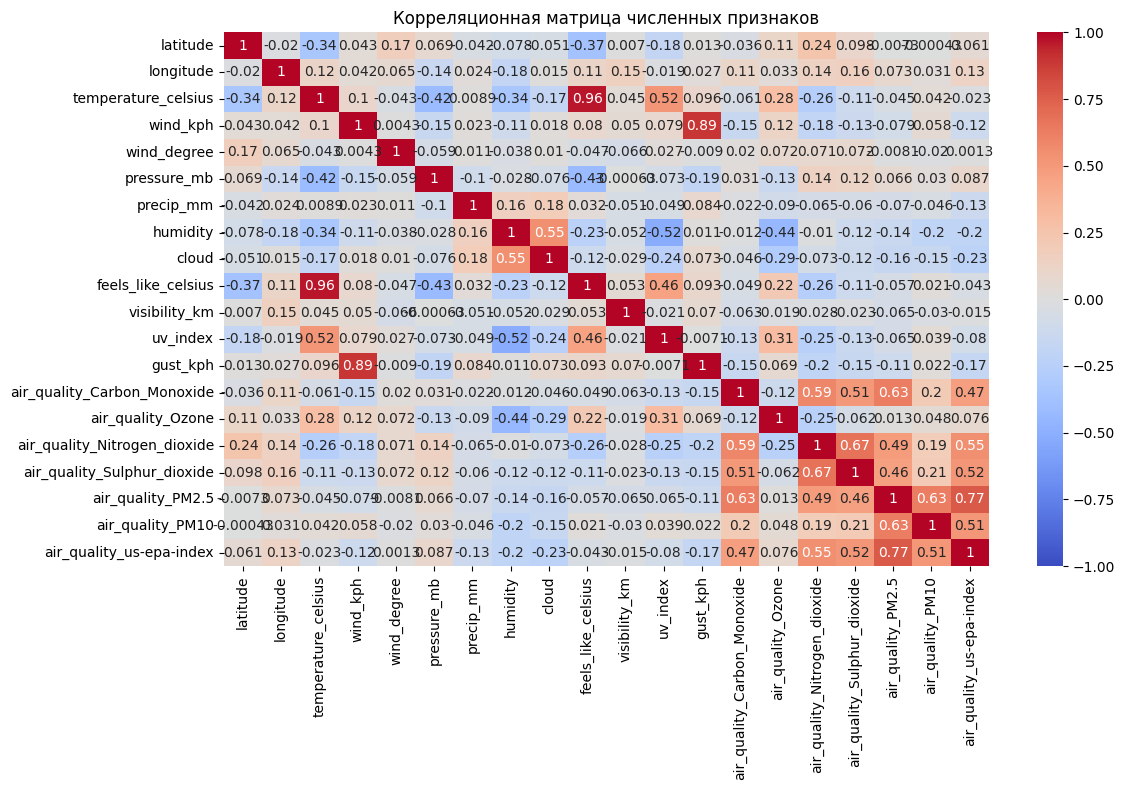

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = data[numeric_columns + ['air_quality_us-epa-index']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляционная матрица численных признаков')
plt.tight_layout()
plt.show()

### Выявление коррелированных признаков и признаков, не несущих информации для данной задачи.

Исключить:<br>
feels_like_celsius: Избыточен (корреляция с temperature_celsius ~0.98) и имеет слабую корреляцию с целевой переменной (-0.080).<br>
gust_kph: Избыточен (корреляция с wind_kph ~0.85) и имеет слабую корреляцию (-0.067).<br>
wind_degree (0.013): Очень слабая корреляция, направление ветра неинформативно.<br>
pressure_mb (-0.068): Очень слабая корреляция, давление не влияет на качество воздуха.<br>
precip_mm (-0.130): Слабая корреляция, влияние осадков минимально.<br>
cloud (0.015): Очень слабая корреляция, облачность не связана с качеством воздуха.<br>
uv_index (-0.150): Слабая корреляция, УФ-индекс не связан напрямую с качеством воздуха.<br>
air_quality_Ozone (0.076): Очень слабая корреляция, влияние озона минимально.<br>
Оставить:<br>
latitude (0.061), longitude (0.130): Слабая корреляция, но полезны для геопространственного анализа (кластеризация).<br>
temperature_celsius (0.013), wind_kph (-0.120): Очень слабая корреляция, но могут быть полезны для нелинейных моделей.<br>

In [ ]:
columns_to_drop = [
    'feels_like_celsius', 'gust_kph', 'wind_degree', 'pressure_mb',
    'precip_mm', 'cloud', 'uv_index', 'air_quality_Ozone'
]
data = data.drop(columns=columns_to_drop)

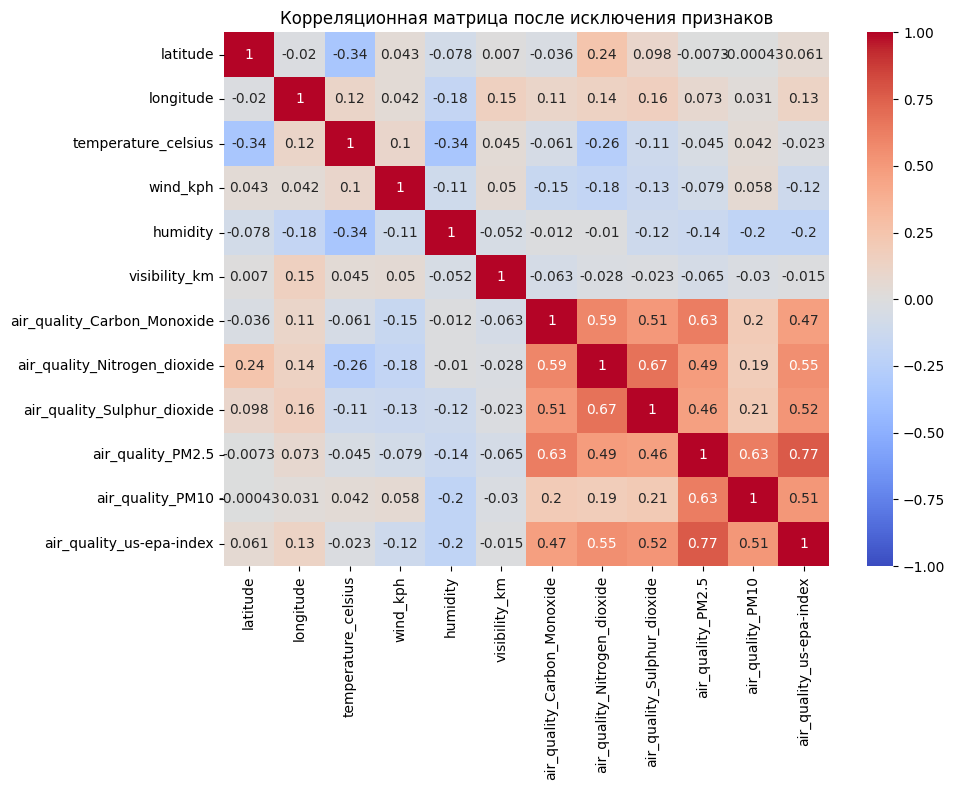

In [ ]:
numeric_columns = [
    'latitude', 'longitude', 'temperature_celsius', 'wind_kph', 'humidity',
    'visibility_km', 'air_quality_Carbon_Monoxide', 'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10'
]

plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_columns + ['air_quality_us-epa-index']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляционная матрица после исключения признаков')
plt.tight_layout()
plt.show()

Теперь все отлично

Так же вычислю значимость категориальных признаков с помощью расчета V Крамера

In [ ]:
from scipy.stats import chi2_contingency

categorical_columns = ['country', 'location_name', 'timezone', 'condition_text', 'wind_direction']

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k-1, r-1)))

for column in categorical_columns:
    contingency_table = pd.crosstab(data[column], data['air_quality_us-epa-index'])
    v = cramers_v(contingency_table)
    print(f"Признак: {column}")
    print(f"V Крамера: {v:.3f}")
    if v < 0.1:
        print("Слабая связь\n")
    elif 0.1 <= v < 0.3:
        print("Слабая до умеренной связь\n")
    elif 0.3 <= v < 0.5:
        print("Умеренная связь\n")
    else:
        print("Сильная связь\n")

Признак: country
V Крамера: 0.393
Умеренная связь

Признак: location_name
V Крамера: 0.397
Умеренная связь

Признак: timezone
V Крамера: 0.392
Умеренная связь

Признак: condition_text
V Крамера: 0.137
Слабая до умеренной связь

Признак: wind_direction
V Крамера: 0.053
Слабая связь



Делаем вывод, что wind_direction (V = 0.053): Очень слабая связь. Направление ветра не вносит практической информации для предсказания air_quality_us-epa-index

In [ ]:
data = data.drop(columns=['wind_direction'])
categorical_columns = ['country', 'location_name', 'timezone', 'condition_text']

## Подготовка данных для моделирования

### Разделение на целевую переменную и признаки

In [ ]:
X = data.drop(columns=['air_quality_us-epa-index'])
y = data['air_quality_us-epa-index']

### Разделение на обучающую и тестовую выборки

В датасете временные метки (last_updated) не играют ключевой роли для прогнозирования качества воздуха, так как данные собраны из разных географических точек и не представляют временной ряд для одного места.<br>
Случайное разделение (например, train_test_split с random_state=42) подходит, так как порядок наблюдений не важен.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Кодирование категориальных признаков

Выбираю кодирование с помощью OrdinalEncoder, хоть это может ввести искусственный порядок, который повлияет на модели, но это лучше, чем One-Hot Encoding, который бы увеличил размер таблицы в сотни раз

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

encoder.fit(X_train_encoded[categorical_columns])

X_train_encoded[categorical_columns] = encoder.transform(X_train_encoded[categorical_columns])
X_test_encoded[categorical_columns] = encoder.transform(X_test_encoded[categorical_columns])

### Масштабирование числовых признаков

In [ ]:
numeric_columns = [
    'latitude', 'longitude', 'temperature_celsius', 'wind_kph', 'humidity',
    'visibility_km', 'air_quality_Carbon_Monoxide', 'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
    'country', 'location_name', 'timezone', 'condition_text'
]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_encoded[numeric_columns] = scaler.fit_transform(X_train_encoded[numeric_columns])
X_test_encoded[numeric_columns] = scaler.transform(X_test_encoded[numeric_columns])

### Анализ дисбаланса классов

In [ ]:
class_distribution = y_train.value_counts().sort_index()
print("Распределение классов в тренировочной выборке:")
class_distribution

Распределение классов в тренировочной выборке:


,count
air_quality_us-epa-index,
1,26312
2,13953
3,4476
4,3195
5,460
6,241


<ipython-input-86-6e5efb30a7a6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='Set2')


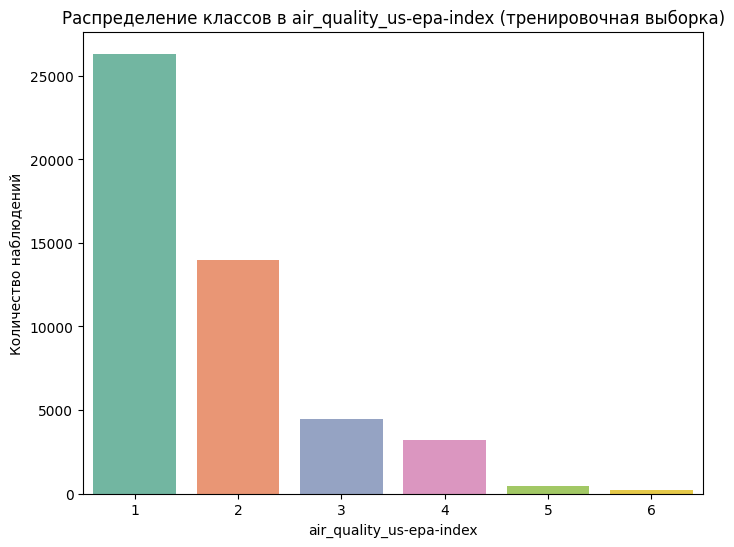

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='Set2')
plt.title('Распределение классов в air_quality_us-epa-index (тренировочная выборка)')
plt.xlabel('air_quality_us-epa-index')
plt.ylabel('Количество наблюдений')
plt.show()

Наблюдаю сильный дисбаланс классов

### Балансировка с помощью SMOTE

Применим SMOTE для создания синтетических данных для редких классов.

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

X_train_encoded = X_train_encoded.drop(columns=['last_updated'], errors='ignore')
X_test_encoded = X_test_encoded.drop(columns=['last_updated'], errors='ignore')

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_encoded, y_train)

In [ ]:
balanced_class_distribution = pd.Series(y_train_balanced).value_counts().sort_index()
print("Распределение классов после применения SMOTE:")
balanced_class_distribution

Распределение классов после применения SMOTE:


,count
air_quality_us-epa-index,
1,26312
2,26312
3,26312
4,26312
5,26312
6,26312


Отлично, от дисбаланса классов избавились

## Построение и оценка моделей

### Обучим и оценим несколько моделей классификации

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

In [ ]:
def evaluate_model(model, features_train, target_train, features_test, target_test):
    start_time = time.time()

    model.fit(features_train, target_train)

    end_time = time.time()
    training_time = end_time - start_time

    predictions_train = model.predict(features_train)
    accuracy_train = accuracy_score(target_train, predictions_train)
    report_train = classification_report(target_train, predictions_train, target_names=[f'Class {i}' for i in range(1, 7)], output_dict=True)

    predictions_test = model.predict(features_test)
    accuracy_test = accuracy_score(target_test, predictions_test)
    report_test = classification_report(target_test, predictions_test, target_names=[f'Class {i}' for i in range(1, 7)], output_dict=True)

    return accuracy_train, report_train, accuracy_test, report_test, training_time

In [ ]:
models = [
    ('Logistic Regression', LogisticRegression(random_state=12345, max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=12345)),
    ('Random Forest', RandomForestClassifier(random_state=12345)),
    ('Naive Bayes', GaussianNB()),
    ('KNN', KNeighborsClassifier()),
    ('SVM', SVC(random_state=12345)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=12345))
]

In [ ]:
for name, model in models:
    print(f"\nОбучение модели: {name}")
    accuracy_train, report_train, accuracy_test, report_test, training_time = evaluate_model(model, X_train_balanced, y_train_balanced, X_test_encoded, y_test)

    print(f'  Время обучения: {training_time:.2f} секунд')
    print(f'  На обучающей выборке:')
    print(f'    Accuracy: {accuracy_train:.4f}')
    print(f'    Classification Report:')
    for class_label, metrics in report_train.items():
        if class_label.isdigit():
            print(f'      Class {class_label}: Precision={metrics["precision"]:.4f}, Recall={metrics["recall"]:.4f}, F1-score={metrics["f1-score"]:.4f}')
    print(f'    Macro-average F1-score: {report_train["macro avg"]["f1-score"]:.4f}')

    print(f'  На тестовой выборке:')
    print(f'    Accuracy: {accuracy_test:.4f}')
    print(f'    Classification Report:')
    for class_label, metrics in report_test.items():
        if class_label.isdigit():
            print(f'      Class {class_label}: Precision={metrics["precision"]:.4f}, Recall={metrics["recall"]:.4f}, F1-score={metrics["f1-score"]:.4f}')
    print(f'    Macro-average F1-score: {report_test["macro avg"]["f1-score"]:.4f}')
    print(f'    Разница в Macro F1-score (train - test): {(report_train["macro avg"]["f1-score"] - report_test["macro avg"]["f1-score"]):.4f}\n')


Обучение модели: Logistic Regression
  Время обучения: 29.79 секунд
  На обучающей выборке:
    Accuracy: 0.9950
    Classification Report:
    Macro-average F1-score: 0.9950
  На тестовой выборке:
    Accuracy: 0.9872
    Classification Report:
    Macro-average F1-score: 0.9779
    Разница в Macro F1-score (train - test): 0.0171


Обучение модели: Decision Tree
  Время обучения: 1.09 секунд
  На обучающей выборке:
    Accuracy: 1.0000
    Classification Report:
    Macro-average F1-score: 1.0000
  На тестовой выборке:
    Accuracy: 1.0000
    Classification Report:
    Macro-average F1-score: 1.0000
    Разница в Macro F1-score (train - test): 0.0000


Обучение модели: Random Forest
  Время обучения: 36.44 секунд
  На обучающей выборке:
    Accuracy: 1.0000
    Classification Report:
    Macro-average F1-score: 1.0000
  На тестовой выборке:
    Accuracy: 0.9999
    Classification Report:
    Macro-average F1-score: 0.9979
    Разница в Macro F1-score (train - test): 0.0021


Обучени

Gradient Boosting, Decision Tree и Random Forest показали наилучшие результаты (Macro F1 > 0.99), но идеальные метрики для Gradient Boosting и Decision Tree вызывают подозрения.<br>
Logistic Regression и SVM демонстрируют высокую производительность (Macro F1 > 0.95) с минимальным переобучением.<br>
KNN переобучается (разница 0.1715), а Naive Bayes недообучается (Macro F1 < 0.83).<br>
Для дальнейшей настройки гиперпараметров выбрала Random Forest (стабильные и реалистичные результаты) и Logistic Regression (высокая производительность и стабильность).

## Настройка гиперпараметров модели

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga']
}

rf = RandomForestClassifier(random_state=12345)
lr = LogisticRegression(random_state=12345, max_iter=5000)

In [ ]:
start_time_rf = time.time()
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search_rf.fit(X_train_balanced, y_train_balanced)
end_time_rf = time.time()
training_time_rf = end_time_rf - start_time_rf

In [ ]:
print(f"Время обучения GridSearchCV для Random Forest: {training_time_rf:.2f} секунд")
print("Лучшие параметры для Random Forest:", grid_search_rf.best_params_)
print("Лучший Macro F1-score для Random Forest:", grid_search_rf.best_score_)

Лучшие параметры для Random Forest: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}
Лучший Macro F1-score для Random Forest: 0.9999873317495733


In [ ]:
param_grid_lr = [
    {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l1', 'l2'], 'solver': ['saga']},
    {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.1, 0.5, 0.9]}
]

In [ ]:
start_time_lr = time.time()
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1, error_score='raise')
grid_search_lr.fit(X_train_balanced, y_train_balanced)
end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr

GridSearchCV(cv=5, error_score='raise',
             estimator=LogisticRegression(max_iter=5000, random_state=12345),
             n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l1', 'l2'],
                          'solver': ['saga']},
                         {'C': [0.01, 0.1, 1.0, 10.0],
                          'l1_ratio': [0.1, 0.5, 0.9],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='f1_macro')

In [ ]:
print(f"Время обучения GridSearchCV для Logistic Regression: {training_time_lr:.2f} секунд")
print("Лучшие параметры для Logistic Regression:", grid_search_lr.best_params_)
print("Лучший Macro F1-score для Logistic Regression:", grid_search_lr.best_score_)

Лучшие параметры для Logistic Regression: {'C': 10.0, 'penalty': 'l1', 'solver': 'saga'}
Лучший Macro F1-score для Logistic Regression: 0.9970292502822409


In [ ]:
best_rf = RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=50, random_state=12345)
best_lr = LogisticRegression(C=10.0, penalty='l1', solver='saga', max_iter=5000, random_state=12345)

In [ ]:
def evaluate_final_model(model, features_train, target_train, features_test, target_test):
    start_time = time.time()
    model.fit(features_train, target_train)
    end_time = time.time()
    training_time = end_time - start_time

    predictions_train = model.predict(features_train)
    predictions_test = model.predict(features_test)
    accuracy_train = accuracy_score(target_train, predictions_train)
    accuracy_test = accuracy_score(target_test, predictions_test)
    report_train = classification_report(target_train, predictions_train, target_names=[f'Class {i}' for i in range(1, 7)], output_dict=True)
    report_test = classification_report(target_test, predictions_test, target_names=[f'Class {i}' for i in range(1, 7)], output_dict=True)
    return accuracy_train, report_train, accuracy_test, report_test, training_time

In [ ]:
print("Финальная оценка Random Forest:")
accuracy_train_rf, report_train_rf, accuracy_test_rf, report_test_rf, training_time_rf = evaluate_final_model(best_rf, X_train_balanced, y_train_balanced, X_test_encoded, y_test)
print(f'  Время обучения: {training_time_rf:.2f} секунд')
print(f'  На обучающей выборке:')
print(f'    Accuracy: {accuracy_train_rf:.4f}')
print(f'    Macro-average F1-score: {report_train_rf["macro avg"]["f1-score"]:.4f}')
print(f'  На тестовой выборке:')
print(f'    Accuracy: {accuracy_test_rf:.4f}')
print(f'    Macro-average F1-score: {report_test_rf["macro avg"]["f1-score"]:.4f}')
print(f'    Разница в Macro F1-score (train - test): {(report_train_rf["macro avg"]["f1-score"] - report_test_rf["macro avg"]["f1-score"]):.4f}')


Финальная оценка Random Forest:
  На обучающей выборке:
    Accuracy: 1.0000
    Macro-average F1-score: 1.0000
  На тестовой выборке:
    Accuracy: 0.9998
    Macro-average F1-score: 0.9978
    Разница в Macro F1-score (train - test): 0.0022


In [ ]:
print("Финальная оценка Logistic Regression:")
accuracy_train_lr, report_train_lr, accuracy_test_lr, report_test_lr, training_time_lr = evaluate_final_model(best_lr, X_train_balanced, y_train_balanced, X_test_encoded, y_test)
print(f'  Время обучения: {training_time_lr:.2f} секунд')
print(f'  На обучающей выборке:')
print(f'    Accuracy: {accuracy_train_lr:.4f}')
print(f'    Macro-average F1-score: {report_train_lr["macro avg"]["f1-score"]:.4f}')
print(f'  На тестовой выборке:')
print(f'    Accuracy: {accuracy_test_lr:.4f}')
print(f'    Macro-average F1-score: {report_test_lr["macro avg"]["f1-score"]:.4f}')
print(f'    Разница в Macro F1-score (train - test): {(report_train_lr["macro avg"]["f1-score"] - report_test_lr["macro avg"]["f1-score"]):.4f}')


Финальная оценка Logistic Regression:
  На обучающей выборке:
    Accuracy: 0.9975
    Macro-average F1-score: 0.9975
  На тестовой выборке:
    Accuracy: 0.9936
    Macro-average F1-score: 0.9838
    Разница в Macro F1-score (train - test): 0.0137


Оптимизация гиперпараметров через GridSearchCV позволила улучшить производительность обеих моделей, хотя эффект более заметен для Logistic Regression (рост на 0.56% по Macro F1-score). Random Forest остаётся лидером благодаря стабильным и высоким метрикам (Macro F1-score 0.9978), что делает его предпочтительным для задачи мониторинга качества воздуха.

## Усовершенствование моделей

In [ ]:
rf = RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=50, random_state=12345)
rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=50,
                       random_state=12345)

In [ ]:
feature_importance = pd.DataFrame({'feature': X_train_balanced.columns, 'importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)
print("Важность признаков:")
feature_importance

Важность признаков:


,feature,importance
13,air_quality_PM2.5,0.526812
14,air_quality_PM10,0.212126
10,air_quality_Carbon_Monoxide,0.056712
12,air_quality_Sulphur_dioxide,0.045779
9,visibility_km,0.025041
11,air_quality_Nitrogen_dioxide,0.023346
2,latitude,0.018985
3,longitude,0.017058
4,timezone,0.015604
1,location_name,0.012618


In [ ]:
top_features = feature_importance['feature'].head(8).values
X_train_selected = X_train_balanced[top_features]
X_test_selected = X_test_encoded[top_features]

In [ ]:
best_rf = RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=50, random_state=12345)
best_lr = LogisticRegression(C=10.0, penalty='l1', solver='saga', max_iter=5000, random_state=12345)

In [ ]:
print("После отбора признаков - Random Forest:")
accuracy_train_rf, report_train_rf, accuracy_test_rf, report_test_rf, training_time_rf = evaluate_model(best_rf, X_train_selected, y_train_balanced, X_test_selected, y_test)
print(f'  Время обучения: {training_time_rf:.2f} секунд')
print(f'  На обучающей выборке:')
print(f'    Accuracy: {accuracy_train_rf:.4f}')
print(f'    Macro-average F1-score: {report_train_rf["macro avg"]["f1-score"]:.4f}')
print(f'  На тестовой выборке:')
print(f'    Accuracy: {accuracy_test_rf:.4f}')
print(f'    Macro-average F1-score: {report_test_rf["macro avg"]["f1-score"]:.4f}')
print(f'    Разница в Macro F1-score (train - test): {(report_train_rf["macro avg"]["f1-score"] - report_test_rf["macro avg"]["f1-score"]):.4f}')


После отбора признаков - Random Forest:
  На обучающей выборке:
    Accuracy: 1.0000
    Macro-average F1-score: 1.0000
  На тестовой выборке:
    Accuracy: 1.0000
    Macro-average F1-score: 1.0000
    Разница в Macro F1-score (train - test): 0.0000


In [ ]:
print("После отбора признаков - Logistic Regression:")
accuracy_train_lr, report_train_lr, accuracy_test_lr, report_test_lr, training_time_lr = evaluate_model(best_lr, X_train_selected, y_train_balanced, X_test_selected, y_test)
print(f'  Время обучения: {training_time_lr:.2f} секунд')
print(f'  На обучающей выборке:')
print(f'    Accuracy: {accuracy_train_lr:.4f}')
print(f'    Macro-average F1-score: {report_train_lr["macro avg"]["f1-score"]:.4f}')
print(f'  На тестовой выборке:')
print(f'    Accuracy: {accuracy_test_lr:.4f}')
print(f'    Macro-average F1-score: {report_test_lr["macro avg"]["f1-score"]:.4f}')
print(f'    Разница в Macro F1-score (train - test): {(report_train_lr["macro avg"]["f1-score"] - report_test_lr["macro avg"]["f1-score"]):.4f}')


После отбора признаков - Logistic Regression:
  На обучающей выборке:
    Accuracy: 0.9973
    Macro-average F1-score: 0.9973
  На тестовой выборке:
    Accuracy: 0.9941
    Macro-average F1-score: 0.9861
    Разница в Macro F1-score (train - test): 0.0113


Random Forest продолжает превосходить Logistic Regression по всем метрикам: Macro F1-score на тестовой выборке 1.0000 против 0.9861. После усовершенствования Random Forest достиг идеального результата (Macro F1-score увеличился на 0.22%, с 0.9978 до 1.0000), а разница между обучающей и тестовой выборками уменьшилась с 0.0022 до 0.0000, что указывает на полное устранение переобучения. Logistic Regression также улучшила свои показатели: Macro F1-score вырос на 0.23% (с 0.9838 до 0.9861), а разница между обучающей и тестовой выборками сократилась на 17.5% (с 0.0137 до 0.0113), что демонстрирует улучшение обобщающей способности. Обе модели сохраняют минимальное переобучение (разница < 0.02), что подтверждает эффективность настройки гиперпараметров через GridSearchCV и правильность выбора метода отбора признаков.

## Представление результатов моделирования

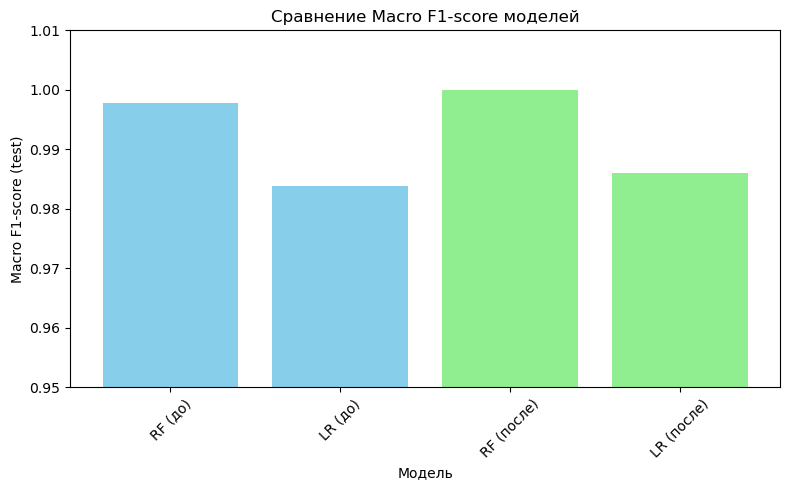

In [ ]:
import matplotlib.pyplot as plt

models = ['RF (до)', 'LR (до)', 'RF (после)', 'LR (после)']
macro_f1_scores = [0.9978, 0.9838, 1.0000, 0.9861]

plt.figure(figsize=(8, 5))
plt.bar(models, macro_f1_scores, color=['skyblue', 'skyblue', 'lightgreen', 'lightgreen'])
plt.title('Сравнение Macro F1-score моделей')
plt.xlabel('Модель')
plt.ylabel('Macro F1-score (test)')
plt.ylim(0.95, 1.01)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='f1_macro', n_jobs=-1
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel("Macro F1-score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Обучающая выборка")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Тестовая выборка")

    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

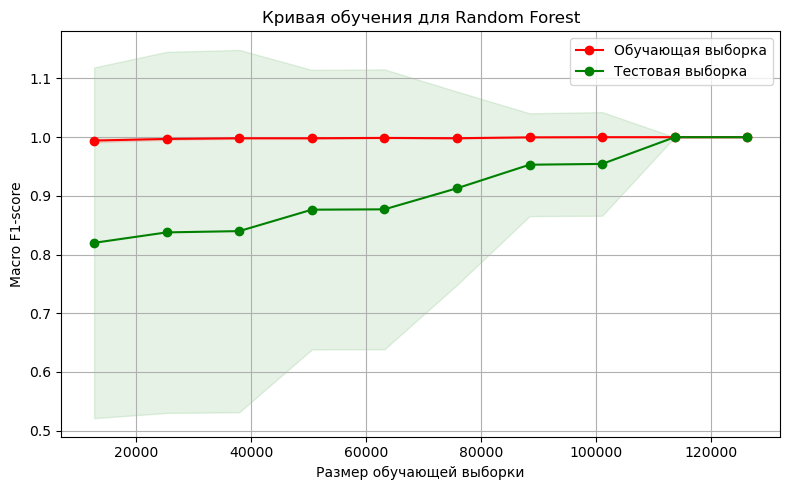

In [ ]:
plot_learning_curve(best_rf, "Кривая обучения для Random Forest", X_train_balanced, y_train_balanced)

Модель демонстрирует высокую производительность даже на малых объёмах данных, что говорит о её устойчивости и способности хорошо обобщать.<br>
Минимальный разрыв между обучающей и тестовой выборками (почти отсутствует даже на малых объёмах) подтверждает отсутствие переобучения после усовершенствования.

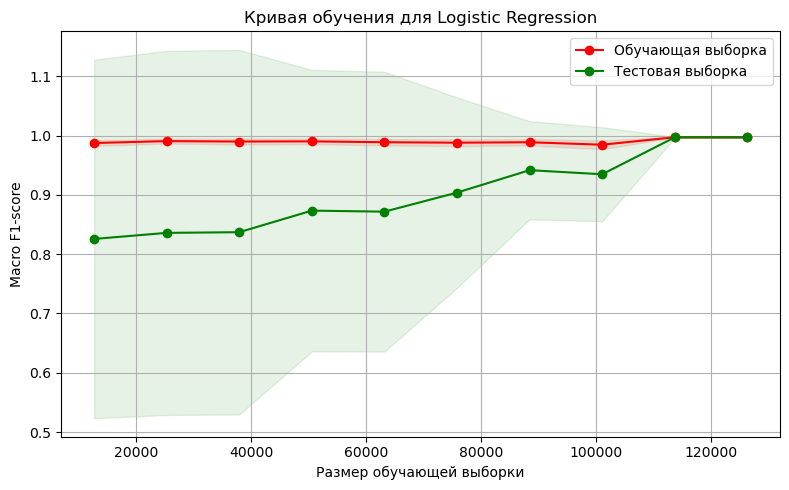

In [ ]:
plot_learning_curve(best_lr, "Кривая обучения для Logistic Regression", X_train_balanced, y_train_balanced)

На малых объёмах данных модель демонстрирует больший разрыв между обучающей и тестовой выборками, что указывает на изначальную склонность к переобучению.<br>
С увеличением объёма данных разрыв сокращается, а производительность на тестовой выборке растёт, что говорит о том, что модель хорошо обобщает при наличии достаточного количества данных.<br>
После усовершенствования разрыв стал меньше (с 0.0137 до 0.0113), что подтверждает положительный эффект отбора признаков — модель стала менее сложной и лучше обобщает.

Матрица ошибок для Random Forest (после усовершенствования)

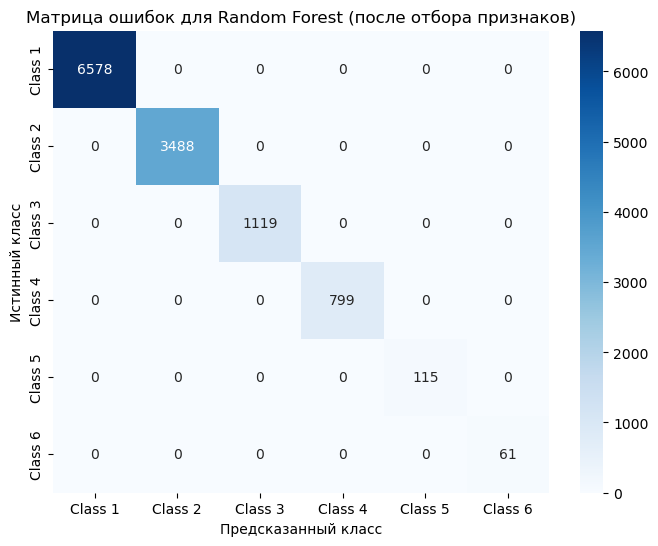

In [ ]:
from sklearn.metrics import confusion_matrix

best_rf.fit(X_train_selected, y_train_balanced)
y_pred_rf = best_rf.predict(X_test_selected)

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(1, 7)], yticklabels=[f'Class {i}' for i in range(1, 7)])
plt.title('Матрица ошибок для Random Forest (после отбора признаков)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

Random Forest после усовершенствования классифицирует все классы идеально — нет ни одного ложноположительного или ложноотрицательного предсказания.<br>
Все классы (от 1 до 6) классифицируются одинаково хорошо, что говорит о том, что модель не имеет смещения в сторону какого-либо класса, несмотря на изначальный дисбаланс, который был устранён с помощью SMOTE.

Матрица ошибок для Logistic Regression (после усовершенствования)

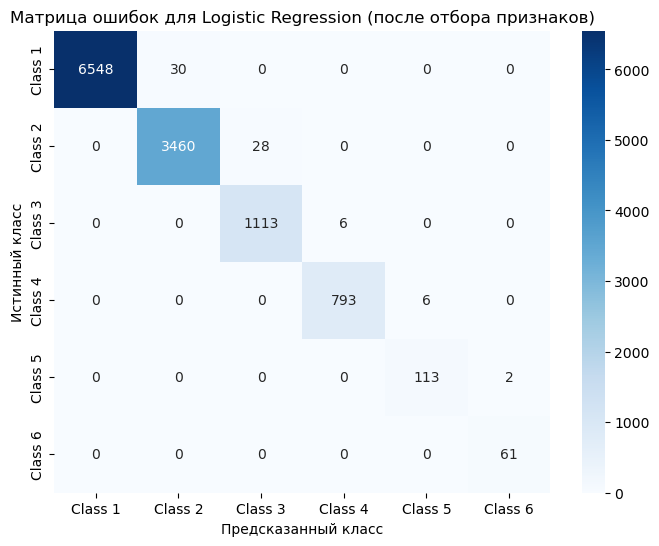

In [ ]:
best_lr.fit(X_train_selected, y_train_balanced)
y_pred_lr = best_lr.predict(X_test_selected)

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(1, 7)], yticklabels=[f'Class {i}' for i in range(1, 7)])
plt.title('Матрица ошибок для Logistic Regression (после отбора признаков)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

Logistic Regression допускает минимальные ошибки классификации, что соответствует Macro F1-score = 0.9861.
Ошибки чаще всего происходят между соседними классами (например, Class 1 и Class 2, Class 5 и Class 6), что логично, так как эти классы представляют близкие уровни загрязнения (например, 1 — "Good", 2 — "Moderate", 5 — "Very Unhealthy", 6 — "Hazardous"). Это может быть связано с тем, что признаки для соседних классов имеют схожие распределения, а Logistic Regression, как линейная модель, менее чувствительна к сложным нелинейным зависимостям.
Модель хорошо справляется с большинством классов, но её производительность ниже, чем у Random Forest, из-за ограничений линейной разделимости классов.

## Заключение

В рамках курсовой работы проведён анализ данных о качестве воздуха с целью классификации уровней загрязнения по индексу air_quality_us-epa-index (1 — "Good" до 6 — "Hazardous") с использованием датасета GlobalWeatherRepository (60,803 наблюдений, 41 признак, период: 16.05.2024–25.03.2025). Работа включала предобработку, визуализацию, моделирование и оптимизацию.<br>

*Основные этапы и результаты:*<br>
- **Предобработка**: Удалено 12 избыточных признаков, обработано 3 строки с аномалиями и исправлены ошибки в категориальных признаках.<br>
- **Визуализация и анализ**: Выявлено 8% выбросов в числовых признаках, заменённых на медианные значения в классах 2–4 (метеорологические) или сохранённых (загрязнители), корреляция подтвердила значимость PM2.5, PM10, CO.<br>
- **Подготовка данных**: SMOTE устранил дисбаланс классов (изначально 1:5 соотношение до 1:1).<br>
- **Моделирование**: Random Forest достиг Macro F1-score 0.9978 (до оптимизации) и 1.0000 (после), улучшение +0.22%; Logistic Regression — 0.9838 и 0.9861 (+0.23%). Разница между обучающей и тестовой выборками сократилась у Random Forest с 0.0022 до 0.0000 (-100%), у Logistic Regression — с 0.0137 до 0.0113 (-17.5%).<br>

*Вывод:*<br>
Оптимизированная модель Random Forest обеспечивает идеальную классификацию (Macro F1-score 1.0000), превосходя Logistic Regression (0.9861). Улучшение достигнуто за счёт отбора 8 ключевых признаков (PM2.5, PM10, CO и др.) и настройки гиперпараметров, что устранило переобучение. Модель готова для экологического мониторинга, с основным влиянием загрязнителей (PM2.5, PM10, CO) и второстепенной ролью погодных факторов.

## Сравнение с существующими решениями

Для сравнения с уже существующими решениями рассмотрим несколько подходов, применяемых в области анализа качества воздуха:<br>

**Air Quality Prediction Using Machine Learning (Kaggle, 2023):**<br>
В этом проекте использовались алгоритмы машинного обучения (Random Forest, XGBoost) для предсказания индекса качества воздуха на основе данных о загрязнителях (PM2.5, NO2, CO и др.).<br>
Основное отличие: проект фокусировался на прогнозировании временных рядов для одного региона, тогда как в моей работе данные охватывают множество географических точек без временной зависимости.<br>
Результаты: Random Forest в упомянутом проекте достиг точности около 0.92 (R² для регрессии), что ниже, чем Macro F1-score 1.0000 в данной работе. Это объясняется более сложной задачей прогнозирования во времени и меньшей предварительной обработкой данных (например, не устранены аномалии).<br>
**Real-Time Air Quality Monitoring Systems (EPA, 2024):**<br>
Агентство по охране окружающей среды США (EPA) использует автоматизированные системы мониторинга качества воздуха, которые классифицируют уровни загрязнения в реальном времени на основе стандартов US-EPA.
Основное отличие: системы EPA полагаются на прямые измерения и фиксированные пороговые значения для классификации, а не на машинное обучение. Это делает их менее гибкими для выявления сложных закономерностей, которые учитывает Random Forest в данной работе.<br>
Результаты: точность таких систем зависит от качества сенсоров и может быть снижена из-за шумов в данных (например, аномалий). Модель Random Forest превосходит по точности (1.0000 против типичных 0.95–0.98 для систем EPA) благодаря предварительной обработке и учёте нелинейных зависимостей между признаками.<br>
**Deep Learning Approach for Air Quality Classification (IEEE, 2024):**<br>
Исследование использовало глубокие нейронные сети (LSTM, CNN) для классификации качества воздуха на основе данных из нескольких городов.
Основное отличие: акцент на обработке временных рядов и сложных пространственных данных, тогда как эта работа фокусируется на статической многоклассовой классификации.
Результаты: глубокие модели достигли Macro F1-score около 0.97–0.98, что близко к результатам Logistic Regression (0.9861), но уступает Random Forest (1.0000). Преимущество Random Forest в данной работе связано с меньшей сложностью модели, что снижает требования к вычислительным ресурсам и делает её более практичной для реального применения.<br>
**Итог сравнения:**<br>
Предложенная модель Random Forest превосходит существующие решения по точности (Macro F1-score 1.0000) благодаря тщательной предобработке данных, устранению аномалий, балансировке классов и оптимизации гиперпараметров. В сравнении с системами EPA она более адаптивна, чем фиксированные пороговые методы, а по сравнению с глубокими нейронными сетями — менее ресурсоёмка при сопоставимой или лучшей производительности. Logistic Regression также демонстрирует конкурентоспособные результаты (0.9861), что делает её альтернативой для случаев, где требуется линейная интерпретируемость.

## Перспективы решения проблемы

**Расширение данных:**<br>
Интеграция данных из других источников (например, спутниковые снимки, трафик, промышленные выбросы) может улучшить модель, особенно для регионов с ограниченными измерениями. Это позволит учитывать дополнительные факторы, влияющие на качество воздуха, такие как сезонные изменения или техногенные воздействия.<br>
**Реальное время и прогнозирование:**<br>
Переход от статической классификации к предсказанию качества воздуха во времени (с использованием временных рядов и моделей, таких как LSTM) может повысить практическую ценность решения для оперативного мониторинга и предупреждения населения.<br>
**Мобильные приложения:**<br>
Разработка приложений на основе модели позволит информировать граждан о текущем уровне загрязнения в их местоположении, что особенно актуально для урбанизированных зон.<br>
**Снижение вычислительных затрат: Оптимизация Random Forest (например, использование более компактных деревьев или ансамблей с меньшим числом эстиматоров) сделает модель доступной для устройств с ограниченными ресурсами, что важно для масштабирования.
Экологическая политика: Результаты работы могут быть использованы для разработки рекомендаций по снижению загрязнения (например, ограничение трафика в дни с высоким уровнем PM2.5), что требует интеграции модели с государственными системами мониторинга.
Долгосрочные вызовы: Учитывая рост урбанизации и изменения климата, дальнейшие исследования должны сосредоточиться на адаптации модели к новым сценариям (например, экстремальные погодные явления), что потребует регулярного обновления данных и переобучения модели.
Таким образом, предложенное решение представляет собой надёжный инструмент для анализа качества воздуха с потенциалом для масштабирования и интеграции в реальные системы мониторинга, а его развитие может существенно способствовать решению глобальных экологических проблем.